<div align="center">

<img src="https://www.udla.edu.ec/wp-content/uploads/2021/03/logo-udla.png" width="220" alt="UDLA"/>

</div>

# Análisis Espacio-Temporal de Accidentes de Tránsito en Ecuador
## Detección de Hotspots con DBSCAN y Pronóstico con Modelos de Series de Tiempo

**Asignatura:** ISWZ3402 – Inteligencia Artificial II · Universidad de Las Américas (UDLA)
**Proyecto Final Integrador**

---

### Integrantes del grupo
<!-- COMPLETAR: un integrante por línea -->
1. Mateo Arguello
2. Joaquin Chacon
3. Andres Jimenez
4. Mathew Baquero
5. Galo Guevara
6. Joel Ibarra

---

**Artículo de referencia (a reproducir):**
Chávez-García, N., Salinas-Carrión, J., Navas-Perrone, A., & González-Rodríguez, M. (2026).
*Spatiotemporal Analysis and Forecasting of Traffic Accidents in Ecuador Using DBSCAN and Ensemble Time Series Modeling.*
**Urban Science, 10**(5), 280. https://doi.org/10.3390/urbansci10050280

**Dataset:** *Ecuador Traffic Accidents* — Agencia Nacional de Tránsito (ANT), enero 2017 – abril 2024.
Kaggle: https://www.kaggle.com/code/alicevangomez/ecu-accidentes  (archivo `BDD_ENE_17_ABR_24.csv`).

---

> **Checklist de entrega (evita penalizaciones):**
> - ✅ Integrantes listados arriba, uno por línea (−1 pt si falta).
> - ✅ Zip con formato `Final_Project_AI2202620_II1II2II3.zip` conteniendo **.ipynb, .html y .pdf** (−1 pt si falta).
> - ✅ Todos los integrantes suben el archivo a la plataforma (−1 pt si falta).
> - ✅ El notebook incluye secciones, fórmulas, investigación y explicación de cada etapa (rúbrica *Excellent*).


## 1. Introducción y planteamiento del problema

### 1.1 Contexto
Los accidentes de tránsito son uno de los principales problemas de salud pública y movilidad
urbana en Ecuador. Según la Agencia Nacional de Tránsito (ANT), en 2021 se registraron
**21 352 siniestros**, con **2 131 fallecidos** y más de **17 000 heridos**. Un rasgo preocupante
es que la reducción del número de siniestros **no** viene acompañada de una reducción proporcional
de la mortalidad, lo que sugiere brechas en las políticas de seguridad vial.

### 1.2 Pregunta de negocio (rol de "consultora de datos")
> **¿Dónde se concentran espacialmente los accidentes de tránsito en Ecuador (hotspots) y
> cómo evolucionará su frecuencia mensual en el futuro cercano?**

### 1.3 Actores y restricciones
- **Actores:** ANT, GADs municipales (Quito, Guayaquil), planificación urbana, servicios de emergencia.
- **Restricción de datos:** fuente administrativa → posible subregistro en zonas rurales; 2024 es un
  año parcial (solo ene–abr) y no debe interpretarse como una caída real.
- **Valor de decisión:** priorizar intervenciones (señalética, reductores de velocidad, controles) en
  las zonas críticas y anticipar los meses de mayor riesgo para planificar recursos.

### 1.4 Metodología del artículo que reproducimos
1. **Parte 1 – Análisis espacial:** *clustering* de densidad **DBSCAN** con distancia **Haversine**
   para detectar hotspots, evaluado con *Silhouette* y *Davies–Bouldin*, y caracterización de las
   zonas por densidad, muertes y heridos.
2. **Parte 2 – Análisis temporal:** serie mensual de accidentes, detección de outliers, y pronóstico
   con **SARIMA**, **Prophet**, **LSTM** y modelos de *ML* (**XGBoost / Random Forest**), combinados
   en un **ensemble** por pesos inversos al RMSE, comparados con **RMSE** y **MAE**.


## 2. Configuración del entorno

La siguiente celda instala las dependencias. En **Google Colab** ejecútala tal cual; en un entorno
local ya configurado puedes omitirla. Fija además una semilla global para reproducibilidad.

In [1]:
# --- Instalación de dependencias (Google Colab) -----------------------------
# Descomenta si estás en Colab / entorno limpio:
# !pip -q install "scikit-learn>=1.3" prophet statsmodels tensorflow \
#                 xgboost folium haversine plotly geopandas

import warnings, os, random
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)

import numpy as np
import pandas as pd
np.random.seed(SEED)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

print("Entorno base listo · pandas", pd.__version__, "· numpy", np.__version__)

Entorno base listo · pandas 2.3.3 · numpy 2.4.3


## 3. Carga y preparación de datos

### 3.1 Origen y variables
El CSV `BDD_ENE_17_ABR_24.csv` de la ANT trae, entre otras, las columnas:

| Columna original | Estandarizada | Descripción |
|---|---|---|
| `LATITUD_Y`, `LONGITUD_X` | `LATITUD`, `LONGITUD` | Coordenadas del siniestro |
| `ANIO`, `MES_1` | `ANIO`, `MES` | Año y mes |
| `FECHA`, `HORA` | `FECHA`, `HORA` | Fecha y hora del evento |
| `FALLECIDOS` | `FALLECIDOS` | N.º de fallecidos (severidad) |
| `LESIONADOS` | `HERIDOS` | N.º de heridos (severidad) |
| `PROVINCIA`, `CANTON` | `PROVINCIA`, `CANTON` | División administrativa |
| `TIPO_DE_SINIESTRO` | `TIPO_ACCIDENTE` | Tipo (choque, atropello, …) |
| `CAUSA_PROBABLE` / `CODIGO_CAUSA` | `CAUSA_ACCIDENTE` | Causa |

> **Nota de reproducibilidad.** El *loader* de abajo usa el CSV real si está disponible. Si no lo
> encuentra, genera un conjunto **sintético calibrado** a las estadísticas publicadas del paper
> (166 685 registros, media ≈ 1 894 acc/mes, predominio de Guayaquil y Quito, caída COVID en 2020).
> Esto permite ejecutar el notebook de punta a punta; **para la entrega final coloca el CSV real**
> y vuelve a ejecutar.

In [4]:
# --- Localización del archivo (con descarga automática desde Kaggle) ----------
import os, glob

CANDIDATE_PATHS = [
    "BDD_ENE_17_ABR_24.csv",
    "../BDD_ENE_17_ABR_24.csv",
    "data/BDD_ENE_17_ABR_24.csv",
    "/content/BDD_ENE_17_ABR_24.csv",
    "/kaggle/input/accidentesecu/BDD_ENE_17_ABR_24.csv",
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

# Si no está local, descargarlo de Kaggle (kagglehub: dataset público, sin token)
if DATA_PATH is None:
    try:
        import kagglehub, shutil
        ruta = kagglehub.dataset_download("alicevangomez/accidentesecu")
        hits = glob.glob(os.path.join(ruta, "**", "*.csv"), recursive=True)
        if hits:
            shutil.copy(hits[0], "BDD_ENE_17_ABR_24.csv")
            DATA_PATH = "BDD_ENE_17_ABR_24.csv"
            print("✓ CSV descargado desde Kaggle.")
    except Exception as e:
        print("Descarga desde Kaggle no disponible:", e)

if DATA_PATH:
    print("CSV real encontrado en:", DATA_PATH)
else:
    print("CSV real NO encontrado → se usará el generador sintético calibrado.")


100%|██████████| 12.0M/12.0M [00:00<00:00, 15.9MB/s]

Extracting files...


✓ CSV descargado desde Kaggle.
CSV real encontrado en: BDD_ENE_17_ABR_24.csv


In [3]:
# --- Loader del CSV real (estructura Kaggle: 56 columnas, encoding latin-1) --
def load_real_data(path):
    df = pd.read_csv(path, delimiter=",", encoding="latin-1", low_memory=False)
    # Renombres según la fuente Kaggle (alicevangomez/ecu-accidentes)
    rename = {"LATITUD_Y":"LATITUD", "LONGITUD_X":"LONGITUD", "MES_1":"MES",
              "LESIONADOS":"HERIDOS", "CAUSA_PROBABLE":"CAUSA_ACCIDENTE",
              "TIPO_DE_SINIESTRO":"TIPO_ACCIDENTE", "DIA_1":"DIA_SEMANA",
              "JERARQUIA_DE_LA_VIA":"JERARQUIA_VIA"}
    df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})
    if "CAUSA_ACCIDENTE" not in df.columns and "CODIGO_CAUSA" in df.columns:
        df = df.rename(columns={"CODIGO_CAUSA":"CAUSA_ACCIDENTE"})
    # MES textual ("ENERO"...) -> numérico si aplica
    if df["MES"].dtype == object and "MES_2" in df.columns:
        df["MES"] = pd.to_numeric(df["MES_2"], errors="coerce")
    # Fecha
    if "FECHA" in df.columns:
        df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")
    else:
        df["FECHA"] = pd.to_datetime(df["ANIO"].astype(str)+"-"+
                                     df["MES"].astype(str).str.zfill(2)+"-01", errors="coerce")
    # Hora -> entero 0..23
    if "HORA" in df.columns:
        df["HORA"] = pd.to_datetime(df["HORA"].astype(str), errors="coerce").dt.hour
        df["HORA"] = df["HORA"].fillna(12).astype(int)
    for c in ["FALLECIDOS","HERIDOS"]:
        if c not in df.columns: df[c] = 0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    for c in ["ANIO","MES"]:
        if c not in df.columns and "FECHA" in df.columns:
            df[c] = getattr(df["FECHA"].dt, "year" if c=="ANIO" else "month")
    for c in ["PROVINCIA","CANTON","TIPO_ACCIDENTE","CAUSA_ACCIDENTE","ZONA","FERIADO"]:
        if c not in df.columns: df[c] = "N/D"
    return df


In [4]:
# --- Generador sintético calibrado al paper (fallback reproducible) ----------
def make_synthetic(n=166_685, seed=SEED):
    rng = np.random.default_rng(seed)
    # Centros urbanos (lat, lon, peso ~ participacion de accidentes)
    centros = [
        ("Guayaquil", -2.170, -79.922, 0.230, 0.008),
        ("Quito",     -0.190, -78.490, 0.150, 0.010),
        ("Cuenca",    -2.900, -79.010, 0.045, 0.010),
        ("Ambato",    -1.241, -78.620, 0.035, 0.010),
        ("Machala",   -3.258, -79.960, 0.030, 0.010),
        ("Manta",     -0.967, -80.708, 0.030, 0.012),
        ("Sto Domingo",-0.253,-79.175, 0.030, 0.012),
        ("Loja",      -3.994, -79.204, 0.020, 0.010),
        ("Portoviejo",-1.055, -80.455, 0.020, 0.012),
        ("Riobamba",  -1.664, -78.654, 0.018, 0.010),
    ]
    resto_w = 1 - sum(c[3] for c in centros)
    pesos = [c[3] for c in centros] + [resto_w]
    idx = rng.choice(len(centros)+1, size=n, p=pesos)
    lat = np.empty(n); lon = np.empty(n); canton = np.empty(n, dtype=object)
    for i,c in enumerate(centros):
        m = idx==i
        k = m.sum()
        lat[m] = rng.normal(c[1], c[4], k); lon[m] = rng.normal(c[2], c[4]*1.2, k)
        canton[m] = c[0]
    m = idx==len(centros); k = m.sum()
    lat[m] = rng.uniform(-4.8, 1.2, k); lon[m] = rng.uniform(-80.8, -75.5, k)
    canton[m] = "Otros"
    # Fechas ene-2017..abr-2024 con estacionalidad + caida COVID 2020
    meses = pd.date_range("2017-01-01","2024-04-30", freq="MS")
    base = 1894 + 361*0.5*np.sin(np.arange(len(meses))*2*np.pi/12)   # estacional
    for j,mth in enumerate(meses):
        if mth.year==2020 and mth.month in (3,4,5,6,7):
            base[j] *= {3:0.57,4:0.27,5:0.46,6:0.61,7:0.60}[mth.month]  # COVID
        if mth.year==2017 and mth.month==12: base[j]*=1.41              # pico dic-2017
    base = np.clip(base,120,None); base = base/base.sum()*n
    counts = np.floor(base).astype(int); counts[-1]+=n-counts.sum()
    fechas = np.concatenate([
        rng.integers(0, pd.Period(m,'M').days_in_month, c) + np.datetime64(m,'D')
        for m,c in zip(meses,counts)])[:n]
    fechas = pd.to_datetime(rng.permutation(fechas))
    # Hora con doble pico 8h y 19h
    horas = np.clip(np.round(rng.choice(
        [7,8,9,12,13,17,18,19,20,22,0,2],
        p=[.09,.11,.08,.07,.07,.09,.12,.13,.08,.06,.06,.04], size=n)),0,23).astype(int)
    fall = (rng.random(n) < 0.055).astype(int)*rng.integers(1,3,n)
    her  = (rng.random(n) < 0.62 ).astype(int)*rng.integers(1,4,n)
    tipos = rng.choice(["CHOQUE LATERAL","CHOQUE FRONTAL","ATROPELLO","VOLCAMIENTO",
                        "CAIDA PASAJERO","ROZAMIENTO","ESTRELLAMIENTO"],
                       p=[.34,.15,.14,.09,.08,.11,.09], size=n)
    causas = rng.choice(["NO RESPETA SEÑALES DE TRANSITO","CONDUCE DESATENTO",
                         "EXCESO DE VELOCIDAD","INVADE CARRIL","EMBRIAGUEZ",
                         "NO GUARDA DISTANCIA","IMPERICIA DEL CONDUCTOR"],
                        p=[.22,.21,.17,.13,.10,.09,.08], size=n)
    zona = np.where(canton=="Otros", "RURAL", "URBANA")
    prov_map = {"Guayaquil":"GUAYAS","Quito":"PICHINCHA","Cuenca":"AZUAY",
                "Ambato":"TUNGURAHUA","Machala":"EL ORO","Manta":"MANABI",
                "Sto Domingo":"SANTO DOMINGO DE LOS TSACHILAS","Loja":"LOJA",
                "Portoviejo":"MANABI","Riobamba":"CHIMBORAZO"}
    otras = ["ESMERALDAS","LOS RIOS","IMBABURA","COTOPAXI","BOLIVAR","CANAR",
             "CARCHI","NAPO","PASTAZA","SUCUMBIOS","ORELLANA","MORONA SANTIAGO",
             "ZAMORA CHINCHIPE","SANTA ELENA","GALAPAGOS"]
    provincia = np.array([prov_map.get(c, "") for c in canton], dtype=object)
    m_otros = provincia == ""
    provincia[m_otros] = rng.choice(otras, size=m_otros.sum())
    df = pd.DataFrame({"FECHA":fechas,"ANIO":fechas.year,"MES":fechas.month,"HORA":horas,
                       "LATITUD":lat,"LONGITUD":lon,"CANTON":canton,"PROVINCIA":provincia,
                       "TIPO_ACCIDENTE":tipos,"CAUSA_ACCIDENTE":causas,
                       "ZONA":zona,"FERIADO":"N/D",
                       "FALLECIDOS":fall,"HERIDOS":her})
    return df.sort_values("FECHA").reset_index(drop=True)

In [5]:
# --- Cargar ------------------------------------------------------------------
if DATA_PATH:
    df_raw = load_real_data(DATA_PATH); FUENTE = "CSV real ANT"
else:
    df_raw = make_synthetic(); FUENTE = "SINTÉTICO calibrado (reemplazar por CSV real)"
print(f"Fuente de datos : {FUENTE}")
print(f"Registros       : {len(df_raw):,}")
print(f"Columnas        : {list(df_raw.columns)}")
df_raw.head()

Fuente de datos : CSV real ANT
Registros       : 166,685
Columnas        : ['Numero', 'ANIO', 'SINIESTROS', 'HERIDOS', 'FALLECIDOS', 'ENTE_DE_CONTROL', 'LATITUD', 'LONGITUD', 'DPA_1', 'PROVINCIA', 'DPA_2', 'CANTON', 'DPA_3', 'PARROQUIA', 'DIRECCION', 'ZONA_PLANIFICACION', 'ZONA', 'ID_DE_LA_VIA', 'NOMBRE_DE_LA_VIA', 'UBICACION_DE_LA_VIA', 'JERARQUIA_VIA', 'FECHA', 'HORA', 'PERIODO_1', 'PERIODO_2', 'DIA_SEMANA', 'DIA_2', 'MES', 'MES_2', 'FERIADO', 'CODIGO_CAUSA', 'CAUSA_ACCIDENTE', 'TIPO_ACCIDENTE', 'TIPO_DE_VEHICULO_1', 'SERVICIO_1', 'AUTOMOVIL', 'BICICLETA', 'BUS', 'CAMION', 'CAMIONETA', 'EMERGENCIAS', 'ESPECIAL', 'FURGONETA', 'MOTOCICLETA', 'NO_IDENTIFICADO', 'SCOOTER_ELECTRICO', 'TRICIMOTO', 'VEHICULO_DEPORTIVO_UTILITARIO', 'SUMA_DE_VEHICULOS', 'TIPO_ID_1', 'EDAD_1', 'SEXO_1', 'CONDICION_1', 'PARTICIPANTE_1', 'CASCO_1', 'CINTURON_1']


,Numero,ANIO,SINIESTROS,HERIDOS,FALLECIDOS,ENTE_DE_CONTROL,LATITUD,LONGITUD,DPA_1,PROVINCIA,...,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,TIPO_ID_1,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1
0,1.0,2017.0,DMQ00001012017,1.0,0.0,AGENCIA METROPOLITANA DE TRANSITO DE QUITO - AMT,-0.083501,-78.417742,17.0,PICHINCHA,...,0.0,0.0,1.0,CEDULA,36.0,MUJER,LESIONADO,PEATON,NO,NO
1,2.0,2017.0,ATM00002012017,1.0,0.0,AGENCIA DE TRANSITO Y MOVILIDAD DE GUAYAQUIL -...,-2.246682,-79.897754,9.0,GUAYAS,...,0.0,0.0,1.0,CEDULA,12.0,HOMBRE,LESIONADO,PEATON,NO,NO
2,3.0,2017.0,PNE00003012017,1.0,0.0,POLICIA NACIONAL DEL ECUADOR,-0.253881,-79.217405,23.0,SANTO DOMINGO DE LOS TSACHILAS,...,0.0,0.0,1.0,CEDULA,26.0,HOMBRE,LESIONADO,PEATON,NO,NO
3,4.0,2017.0,DMQ00004012017,0.0,0.0,AGENCIA METROPOLITANA DE TRANSITO DE QUITO - AMT,-0.116059,-78.464188,17.0,PICHINCHA,...,0.0,0.0,1.0,NO IDENTIFICADO,-1.0,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
4,5.0,2017.0,DMQ00005012017,0.0,0.0,AGENCIA METROPOLITANA DE TRANSITO DE QUITO - AMT,-0.239721,-78.512058,17.0,PICHINCHA,...,0.0,0.0,1.0,CEDULA,11.0,HOMBRE,ILESO,PASAJERO,NO,NO


### 3.2 Limpieza de datos
Pasos aplicados:
1. **Coordenadas inválidas** → Ecuador continental+insular está en lat ∈ [−5.0, 1.5], lon ∈ [−81.5, −75.0].
2. **Duplicados** exactos.
3. **Severidad** no negativa; imputación de nulos a 0 (ausencia de registro = 0 víctimas).
4. **Variable derivada** `GRAVEDAD` = MORTAL / GRAVE / LEVE para el EDA.

In [6]:
# --- Diagnóstico de calidad ANTES de limpiar (valores faltantes y consistencia) --
cols_rel = [c for c in ["FECHA","HORA","LATITUD","LONGITUD","FALLECIDOS","HERIDOS",
                        "PROVINCIA","CANTON","TIPO_ACCIDENTE","CAUSA_ACCIDENTE","ZONA"]
            if c in df_raw.columns]
calidad = pd.DataFrame({
    "dtype":      df_raw[cols_rel].dtypes.astype(str),
    "n_nulos":    df_raw[cols_rel].isna().sum(),
    "%_nulos":    (df_raw[cols_rel].isna().mean()*100).round(2),
    "n_unicos":   df_raw[cols_rel].nunique(),
})
print("=== Calidad de datos (previo a limpieza) ===")
display(calidad)
print(f"Duplicados exactos: {df_raw.duplicated().sum():,}")
print(f"Coordenadas (0,0) o placeholder: "
      f"{((df_raw['LATITUD']==0)&(df_raw['LONGITUD']==0)).sum():,}")

=== Calidad de datos (previo a limpieza) ===


,dtype,n_nulos,%_nulos,n_unicos
FECHA,datetime64[ns],1,0.0,2677
HORA,int64,0,0.0,24
LATITUD,float64,1,0.0,128555
LONGITUD,float64,1,0.0,124014
FALLECIDOS,float64,0,0.0,17
HERIDOS,float64,0,0.0,38
PROVINCIA,object,1,0.0,24
CANTON,object,1,0.0,225
TIPO_ACCIDENTE,object,1,0.0,13
CAUSA_ACCIDENTE,object,1,0.0,27


Duplicados exactos: 0
Coordenadas (0,0) o placeholder: 0


In [7]:
# Ecuador CONTINENTAL + INSULAR (Galápagos: lon ≈ −92 a −89) — no excluir regiones
LAT_MIN, LAT_MAX = -5.1, 2.0
LON_MIN, LON_MAX = -92.6, -75.0

df = df_raw.copy()
n0 = len(df)
# 1) Fechas nulas o inválidas
nfec = df["FECHA"].isna().sum()
df = df.dropna(subset=["FECHA"])
# 2) Coordenadas fuera del territorio ecuatoriano (incluye el placeholder ~-75.0 del CSV)
mask = df["LATITUD"].between(LAT_MIN,LAT_MAX) & df["LONGITUD"].between(LON_MIN,LON_MAX)
print(f"Fechas inválidas eliminadas   : {nfec:,}")
print(f"Coordenadas fuera de rango    : {(~mask).sum():,} ({(~mask).mean()*100:.2f}%)")
df = df[mask]
# 3) Duplicados exactos
ndup = df.duplicated().sum(); df = df.drop_duplicates()
# 4) Severidad no negativa; nulos = 0 víctimas
df["FALLECIDOS"] = df["FALLECIDOS"].clip(lower=0).fillna(0).astype(int)
df["HERIDOS"]    = df["HERIDOS"].clip(lower=0).fillna(0).astype(int)
# 5) Variables derivadas
df["GRAVEDAD"] = np.where(df["FALLECIDOS"]>0,"MORTAL",
                 np.where(df["HERIDOS"]>0,"GRAVE","LEVE"))
df["FECHA"] = pd.to_datetime(df["FECHA"])
dias = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
df["DIA_SEM_N"] = df["FECHA"].dt.dayofweek
df["DIA_SEM"]   = df["DIA_SEM_N"].map(dict(enumerate(dias)))
df = df.sort_values("FECHA").reset_index(drop=True)
print(f"Duplicados eliminados         : {ndup:,}")
print(f"Dataset limpio: {len(df):,} filas ({n0-len(df):,} descartadas) · "
      f"{df['FECHA'].min().date()} → {df['FECHA'].max().date()}")


Fechas inválidas eliminadas   : 1
Coordenadas fuera de rango    : 2 (0.00%)
Duplicados eliminados         : 0
Dataset limpio: 166,682 filas (3 descartadas) · 2017-01-01 → 2024-04-30


## 4. Análisis exploratorio (EDA)
Antes de modelar, describimos las variables clave: distribución temporal (año/mes/hora),
severidad y concentración geográfica.

In [8]:
print("=== Estadísticas descriptivas (numéricas) ===")
display(df[["FALLECIDOS","HERIDOS","HORA","LATITUD","LONGITUD"]].describe().round(3))
print("\n=== Distribución por gravedad ===")
print(df["GRAVEDAD"].value_counts().to_string())
print(f"\nTotal fallecidos: {df['FALLECIDOS'].sum():,} · Total heridos: {df['HERIDOS'].sum():,}")
print(f"% registros con al menos 1 fallecido: {(df['FALLECIDOS']>0).mean()*100:.2f}%")

=== Estadísticas descriptivas (numéricas) ===


,FALLECIDOS,HERIDOS,HORA,LATITUD,LONGITUD
count,166682.000,166682.000,166682.000,166682.000,166682.000
mean,0.093,0.814,12.599,-1.472,-79.324
std,0.354,1.106,6.593,1.093,0.763
min,0.000,0.000,0.000,-4.966,-91.108
25%,0.000,0.000,7.000,-2.195,-79.905
50%,0.000,1.000,13.000,-1.683,-79.443
75%,0.000,1.000,18.000,-0.279,-78.551
max,22.000,48.000,23.000,1.366,-75.865



=== Distribución por gravedad ===
GRAVEDAD
GRAVE     89417
LEVE      63520
MORTAL    13745

Total fallecidos: 15,450 · Total heridos: 135,734
% registros con al menos 1 fallecido: 8.25%


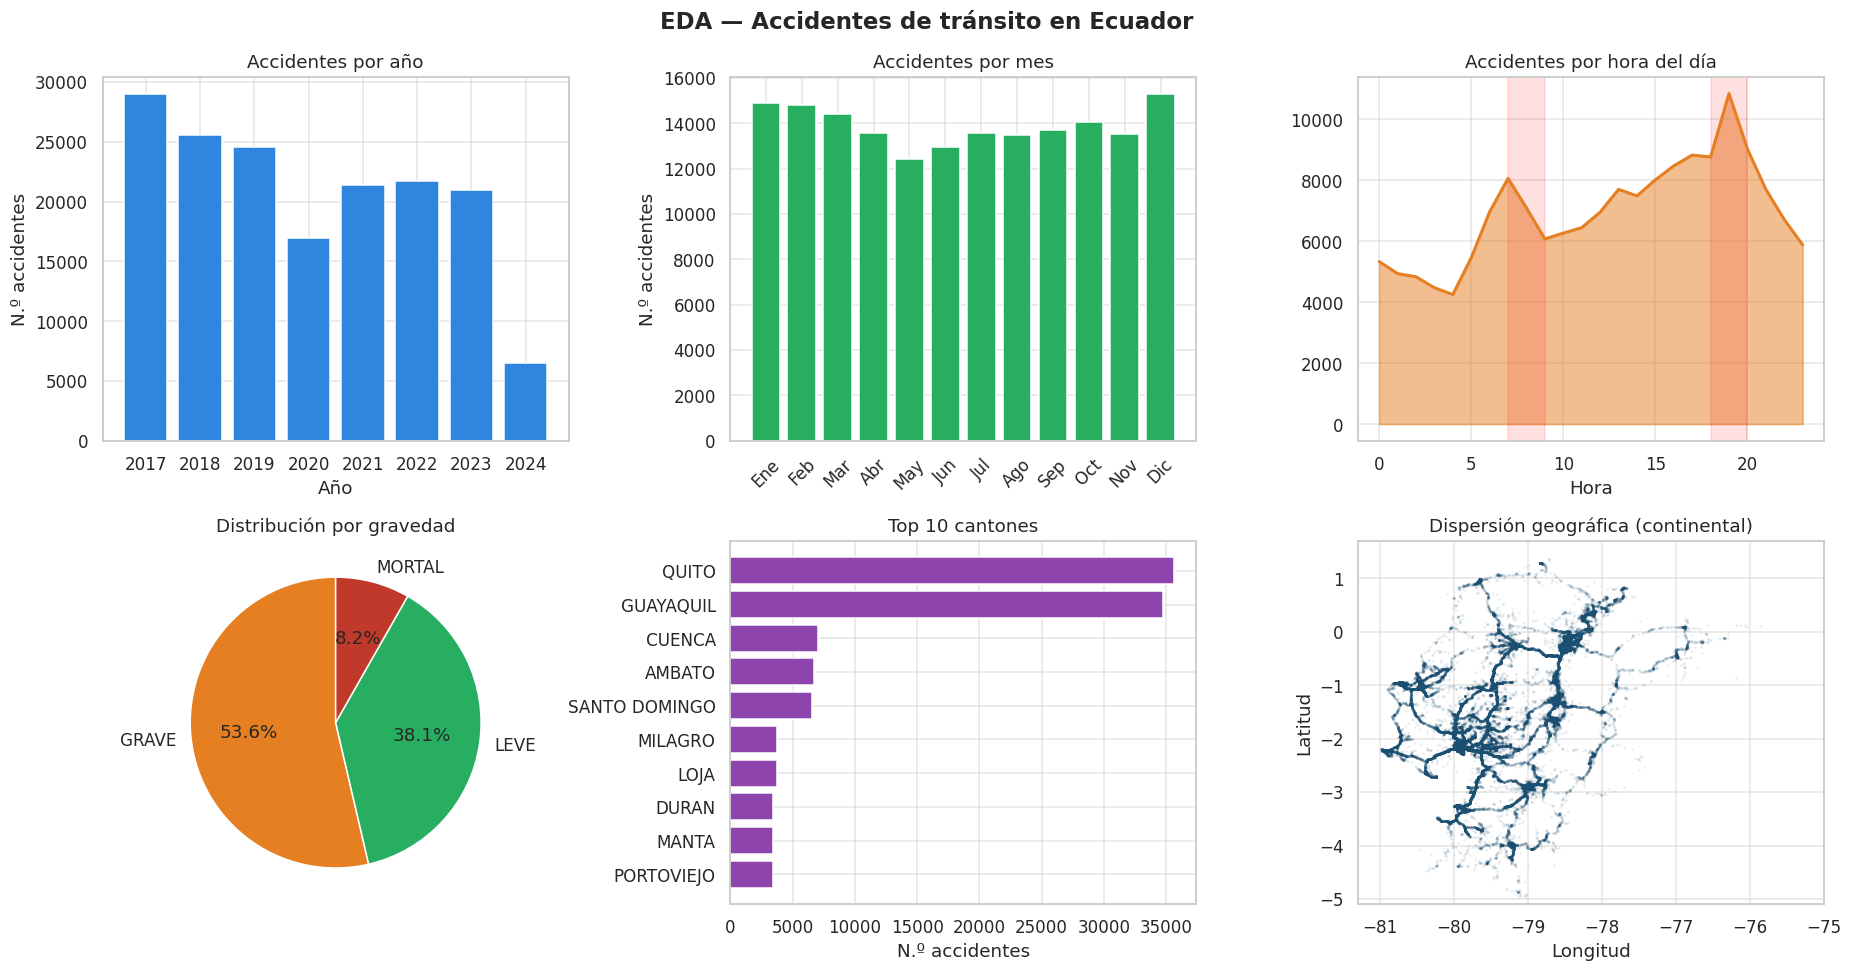

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(17,9))
fig.suptitle("EDA — Accidentes de tránsito en Ecuador", fontsize=15, fontweight="bold")

y = df.groupby("ANIO").size()
ax[0,0].bar(y.index, y.values, color="#2E86DE"); ax[0,0].set_title("Accidentes por año")
ax[0,0].set_xlabel("Año"); ax[0,0].set_ylabel("N.º accidentes")

meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
mth = df.groupby("MES").size().reindex(range(1,13), fill_value=0)
ax[0,1].bar(range(1,13), mth.values, color="#27AE60")
ax[0,1].set_xticks(range(1,13)); ax[0,1].set_xticklabels(meses, rotation=45)
ax[0,1].set_title("Accidentes por mes"); ax[0,1].set_ylabel("N.º accidentes")

hr = df.groupby("HORA").size().reindex(range(24), fill_value=0)
ax[0,2].fill_between(hr.index, hr.values, alpha=.5, color="#E67E22")
ax[0,2].plot(hr.index, hr.values, color="#E67E22", lw=2)
ax[0,2].set_title("Accidentes por hora del día"); ax[0,2].set_xlabel("Hora")
ax[0,2].axvspan(7,9,alpha=.12,color="red"); ax[0,2].axvspan(18,20,alpha=.12,color="red")

g = df["GRAVEDAD"].value_counts()
cmap={"MORTAL":"#C0392B","GRAVE":"#E67E22","LEVE":"#27AE60"}
ax[1,0].pie(g.values, labels=g.index, autopct="%1.1f%%", colors=[cmap[k] for k in g.index],
            startangle=90); ax[1,0].set_title("Distribución por gravedad")

top = df.groupby("CANTON").size().nlargest(10)[::-1]
ax[1,1].barh(top.index, top.values, color="#8E44AD"); ax[1,1].set_title("Top 10 cantones")
ax[1,1].set_xlabel("N.º accidentes")

ax[1,2].scatter(df["LONGITUD"], df["LATITUD"], s=1, alpha=.05, color="#1B4F72")
ax[1,2].set_xlim(-81.3, -75.0); ax[1,2].set_ylim(-5.1, 1.7)   # zoom continental
ax[1,2].set_title("Dispersión geográfica (continental)")
ax[1,2].set_xlabel("Longitud"); ax[1,2].set_ylabel("Latitud")

plt.tight_layout(); plt.savefig("fig_eda.png", bbox_inches="tight"); plt.show()

### 4.1 Tipología, causas y patrón semanal (variables del dataset ANT/Kaggle)

El CSV real incluye `TIPO_DE_SINIESTRO` (13 categorías, con fuerte desbalance hacia
*Choque Lateral*) y `CAUSA_PROBABLE`. Analizamos frecuencia **y** severidad (letalidad por tipo),
además del patrón conjunto día de la semana × hora, clave para focalizar operativos.

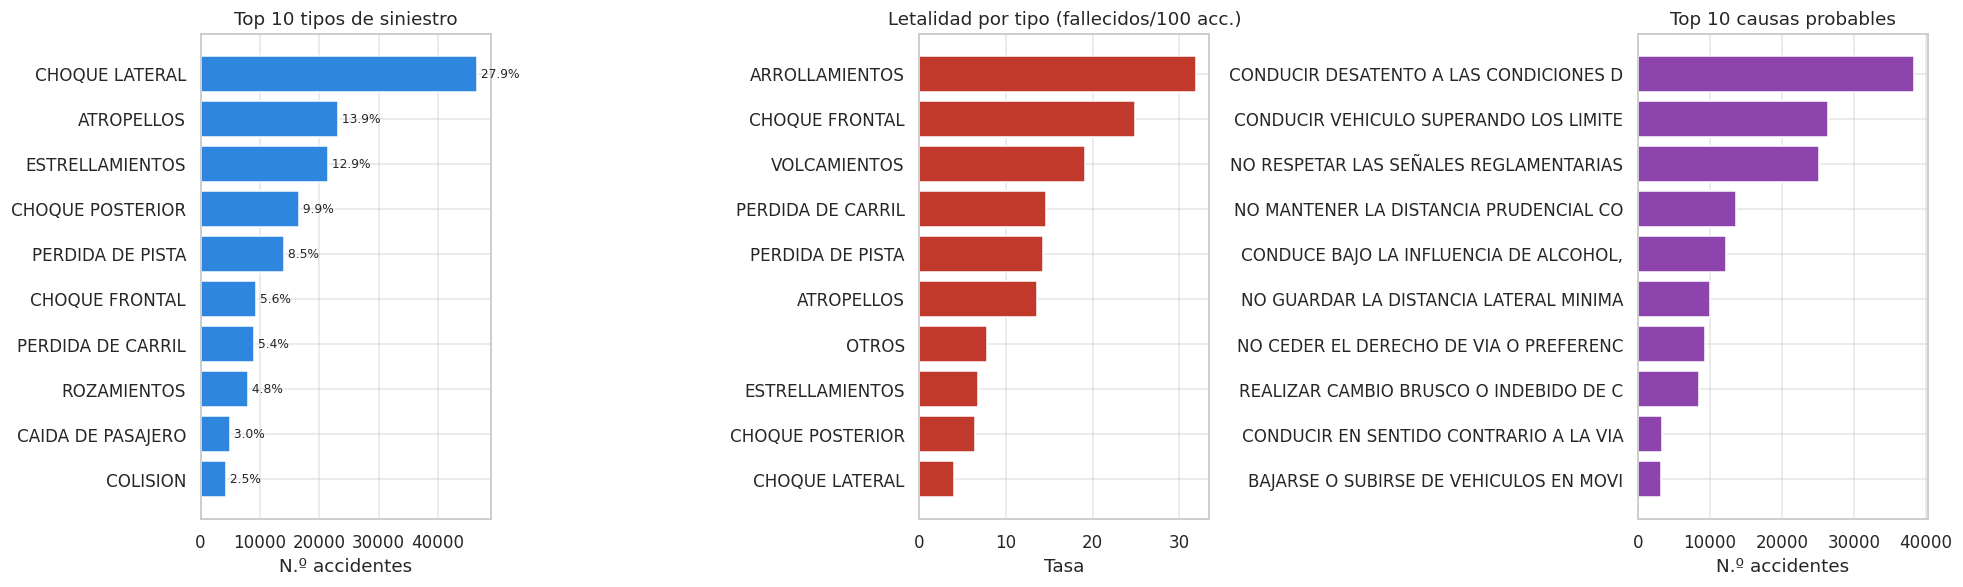

Hallazgo: los tipos MÁS FRECUENTES (choque lateral) no son los MÁS LETALES (atropellos, choques frontales, arrollamientos) → priorizar por severidad, no solo volumen.


In [10]:
fig, ax = plt.subplots(1,3, figsize=(18,5.5))

tipo = df["TIPO_ACCIDENTE"].value_counts().head(10)[::-1]
ax[0].barh(tipo.index, tipo.values, color="#2E86DE")
ax[0].set_title("Top 10 tipos de siniestro"); ax[0].set_xlabel("N.º accidentes")
for i,v in enumerate(tipo.values):
    ax[0].text(v, i, f" {v/len(df)*100:.1f}%", va="center", fontsize=8)

# Letalidad por tipo (fallecidos por cada 100 accidentes) — frecuencia ≠ severidad
let = (df.groupby("TIPO_ACCIDENTE")
         .agg(n=("FALLECIDOS","size"), f=("FALLECIDOS","sum"))
         .query("n >= 200").assign(let=lambda d: d.f/d.n*100)
         .sort_values("let").tail(10))
ax[1].barh(let.index, let["let"], color="#C0392B")
ax[1].set_title("Letalidad por tipo (fallecidos/100 acc.)"); ax[1].set_xlabel("Tasa")

if df["CAUSA_ACCIDENTE"].nunique() > 1:
    causa = df["CAUSA_ACCIDENTE"].astype(str).str.slice(0,38).value_counts().head(10)[::-1]
    ax[2].barh(causa.index, causa.values, color="#8E44AD")
    ax[2].set_title("Top 10 causas probables"); ax[2].set_xlabel("N.º accidentes")
else:
    ax[2].axis("off"); ax[2].set_title("Causa no disponible en esta fuente")
plt.tight_layout(); plt.savefig("fig_tipos_causas.png", bbox_inches="tight"); plt.show()

print("Hallazgo: los tipos MÁS FRECUENTES (choque lateral) no son los MÁS LETALES "
      "(atropellos, choques frontales, arrollamientos) → priorizar por severidad, no solo volumen.")

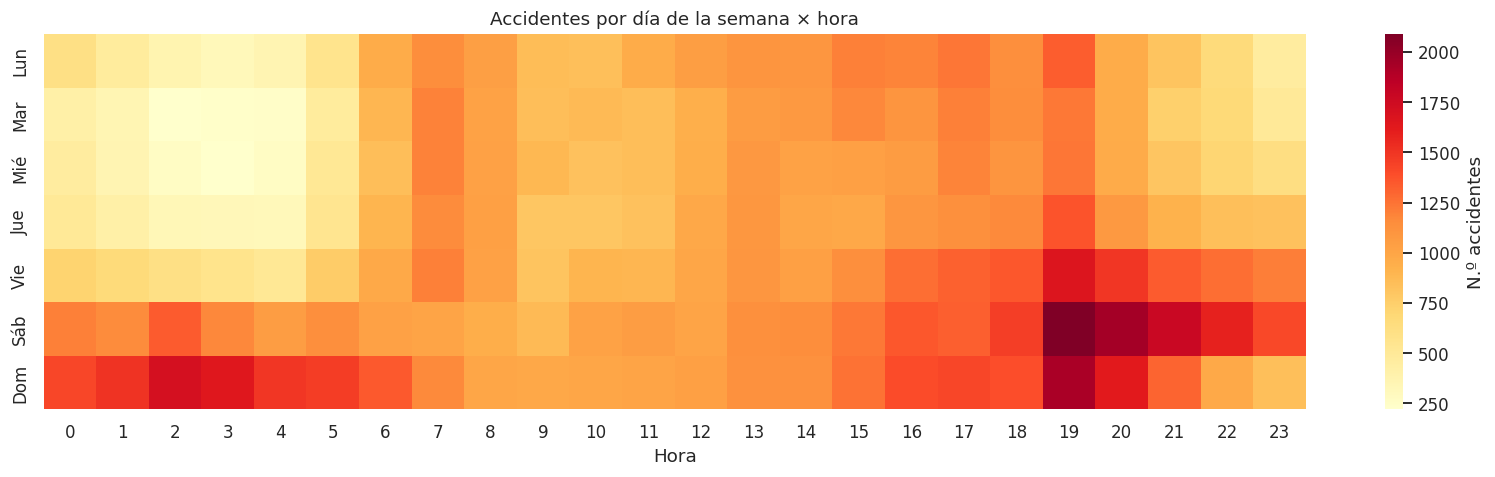

Lectura: picos laborales 07–09 h y 18–20 h (Lun–Vie) y madrugadas de fin de semana (Sáb–Dom 00–03 h), asociadas a conducción nocturna/embriaguez.


In [11]:
# Patrón conjunto día de la semana × hora
piv_dh = (df.groupby(["DIA_SEM_N","HORA"]).size().unstack(fill_value=0)
            .reindex(index=range(7), columns=range(24), fill_value=0))
piv_dh.index = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
plt.figure(figsize=(15,4.5))
sns.heatmap(piv_dh, cmap="YlOrRd", cbar_kws={"label":"N.º accidentes"})
plt.title("Accidentes por día de la semana × hora"); plt.xlabel("Hora"); plt.ylabel("")
plt.tight_layout(); plt.savefig("fig_dia_hora.png", bbox_inches="tight"); plt.show()
print("Lectura: picos laborales 07–09 h y 18–20 h (Lun–Vie) y madrugadas de fin de semana "
      "(Sáb–Dom 00–03 h), asociadas a conducción nocturna/embriaguez.")

### 4.2 Mapas del Ecuador — regiones continental e insular

Se usan los **límites oficiales GADM 4.1** (provincias, incluye Galápagos). Se presentan:
(i) **choropleth** de accidentes por provincia, (ii) mapa de **puntos** de todos los siniestros
sobre las provincias, y (iii) **mapa de calor de severidad** con fallecidos (rojos, tamaño ∝ víctimas)
y heridos (azules). Los nombres de provincia del CSV se normalizan (acentos, alias como
*Santo Domingo → Santo Domingo de los Tsáchilas*) para el match con GADM.

⚠ Provincias del CSV sin match en GADM: ['EL ORO', 'LOS RIOS', 'MORONA SANTIAGO', 'SANTA ELENA', 'SANTO DOMINGO DE LOS TSACHILAS', 'ZAMORA CHINCHIPE']


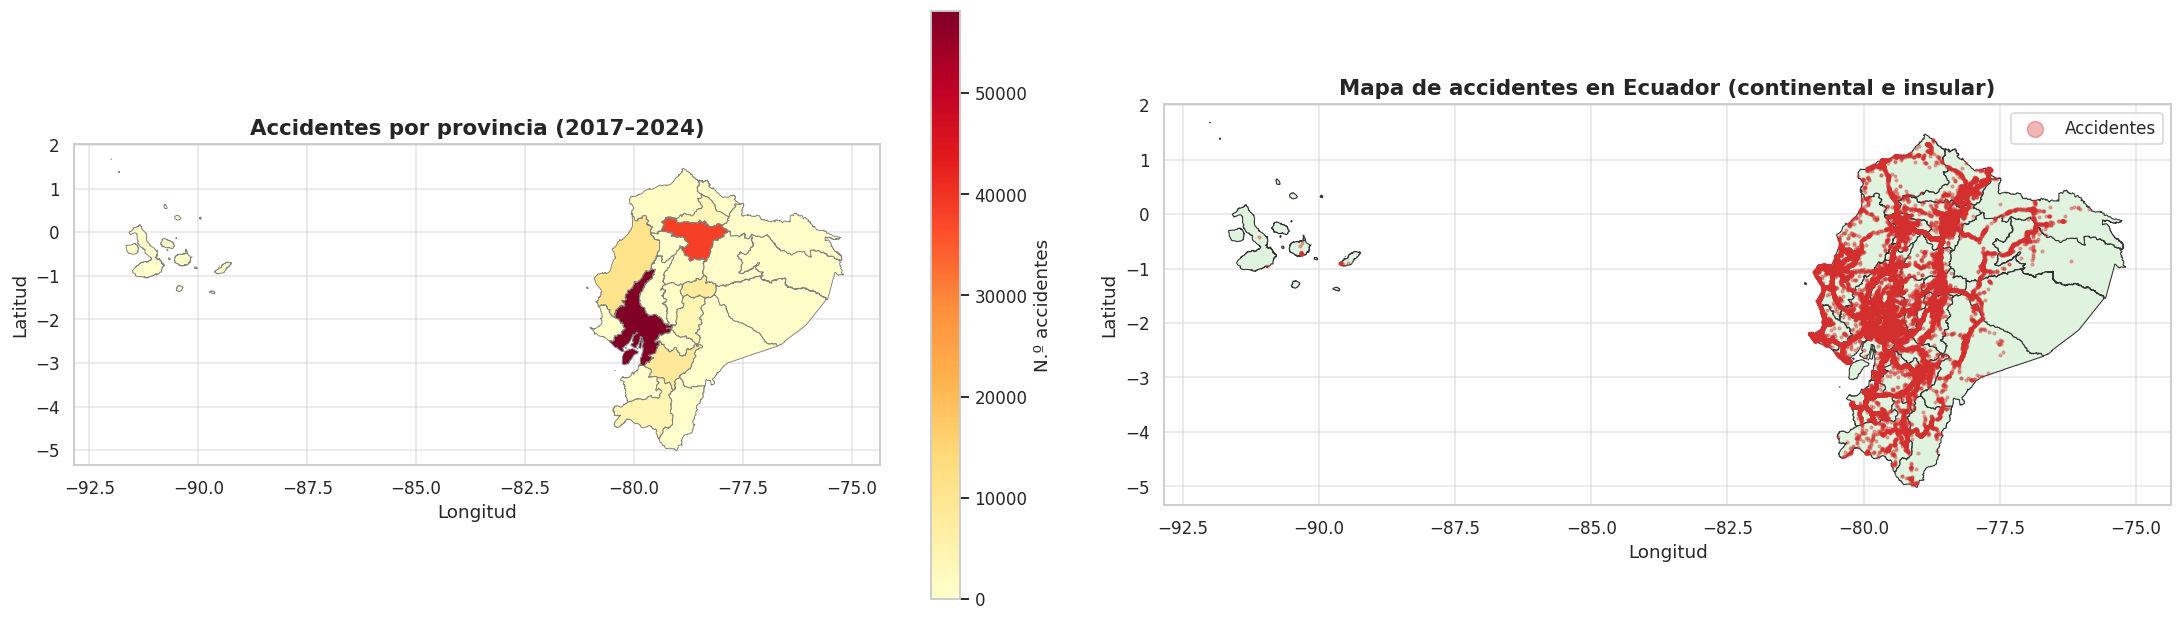

Top 5 provincias: Guayas (58,145), Pichincha (38,309), Manabi (10,766), Azuay (8,653), Tungurahua (8,095)


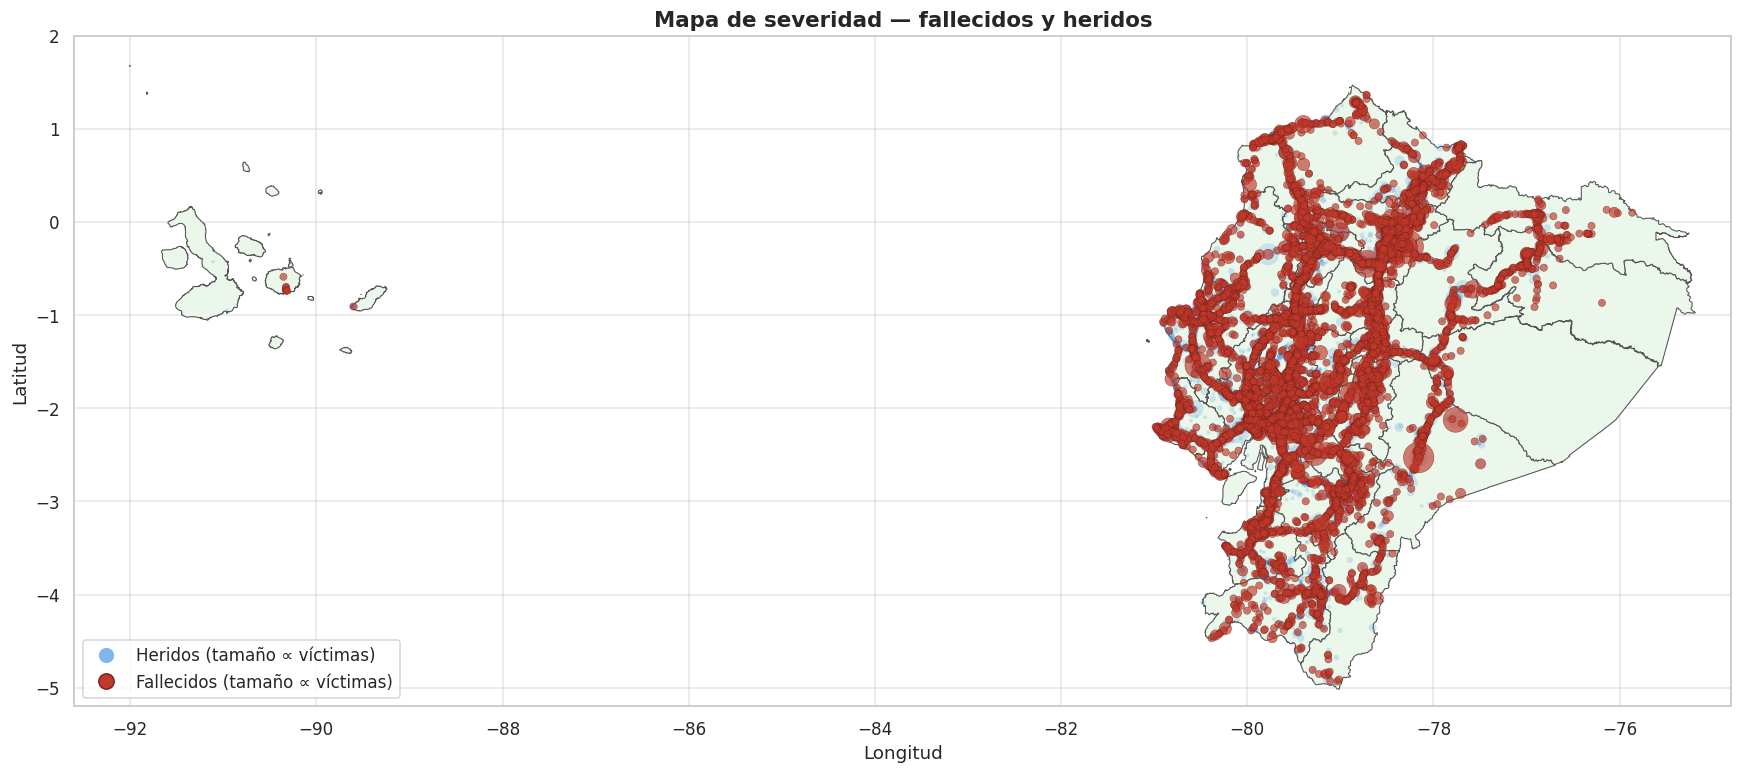

Lectura: los heridos se concentran en corredores urbanos (Guayas–Pichincha), mientras los siniestros mortales se dispersan hacia vías interprovinciales.


In [12]:
# --- Mapas del Ecuador con límites oficiales (GeoPandas + GADM 4.1) -----------
# Soporta: (a) GeoJSON ya descargado, (b) shapefile local/Kaggle, (c) descarga automática.
import unicodedata
def _norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode()
    return s.upper().strip()

# Alias PROVINCIA (ANT) → NAME_1 (GADM) para nombres que difieren
ALIAS_PROV = {"SANTO DOMINGO":"SANTO DOMINGO DE LOS TSACHILAS",
              "STO DGO TSACHILAS":"SANTO DOMINGO DE LOS TSACHILAS",
              "STO DOMINGO TSACHILAS":"SANTO DOMINGO DE LOS TSACHILAS"}

ecuador = None
try:
    import geopandas as gpd
    CANDIDATOS = ["gadm41_ECU_1.json", "gadm41_ECU_1.shp",
                  "/kaggle/input/ecugadm/gadm41_ECU_1.shp",
                  "/content/gadm41_ECU_1.json"]
    ruta = next((c for c in CANDIDATOS if os.path.exists(c)), None)
    if ruta is None:
        import urllib.request, zipfile, io
        url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_ECU_1.json.zip"
        z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url, timeout=60).read()))
        z.extractall("."); ruta = "gadm41_ECU_1.json"
    ecuador = gpd.read_file(ruta)
    ecuador["PROV_N"] = ecuador["NAME_1"].map(_norm)
    gdf_acc = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["LONGITUD"], df["LATITUD"]),
                               crs="EPSG:4326")
except Exception as e:
    print("GADM/geopandas no disponible → gráficos sin límites:", e)

# ═══ Figura 1: choropleth por provincia + mapa de puntos (estilo Kaggle) ═══════
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

prov = (df.assign(PROV_N=df["PROVINCIA"].map(_norm).replace(ALIAS_PROV))
          .groupby("PROV_N").size().rename("n_acc").reset_index())
if ecuador is not None:
    eplot = ecuador.merge(prov, on="PROV_N", how="left").fillna({"n_acc": 0})
    sin_match = sorted(set(prov["PROV_N"]) - set(ecuador["PROV_N"]))
    if sin_match: print("⚠ Provincias del CSV sin match en GADM:", sin_match)
    eplot.plot(column="n_acc", cmap="YlOrRd", linewidth=.6, edgecolor="grey",
               legend=True, legend_kwds={"label":"N.º accidentes","shrink":.7}, ax=ax[0])
    ax[0].set_title("Accidentes por provincia (2017–2024)", fontweight="bold", fontsize=14)

    # Estilo Kaggle: provincias en verde claro + todos los accidentes en rojo
    ecuador.plot(ax=ax[1], color="#DFF3DF", edgecolor="#333333", linewidth=.7)
    gdf_acc.plot(ax=ax[1], color="#D32F2F", markersize=3, alpha=.35, label="Accidentes")
    ax[1].set_title("Mapa de accidentes en Ecuador (continental e insular)",
                    fontweight="bold", fontsize=14)
    ax[1].legend(markerscale=6)
else:
    ax[0].axis("off")
    ax[1].scatter(df["LONGITUD"], df["LATITUD"], s=1, alpha=.05, c="red")
    ax[1].set_title("Distribución geográfica de accidentes", fontweight="bold")
for a in ax: a.set_xlabel("Longitud"); a.set_ylabel("Latitud")
plt.tight_layout(); plt.savefig("fig_mapa_ecuador.png", bbox_inches="tight"); plt.show()

top_prov = prov.sort_values("n_acc", ascending=False).head(5)
print("Top 5 provincias:", ", ".join(f"{r.PROV_N.title()} ({r.n_acc:,})"
                                     for r in top_prov.itertuples()))

# ═══ Figura 2: mapa de severidad — heridos (azul) y fallecidos (rojo) ═════════
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(16, 9))
her = df[df["HERIDOS"]>0]; mor = df[df["FALLECIDOS"]>0]
if ecuador is not None:
    ecuador.plot(ax=ax, color="#EAF7EA", edgecolor="#555555", linewidth=.7)
# Heridos: azul sólido, tamaño ∝ víctimas (capa base)
ax.scatter(her["LONGITUD"], her["LATITUD"], s=her["HERIDOS"]*6,
           c="#2E86DE", alpha=.18, edgecolors="none")
# Fallecidos: rojo intenso con borde, encima (capa prioritaria)
ax.scatter(mor["LONGITUD"], mor["LATITUD"], s=mor["FALLECIDOS"]*22,
           c="#C0392B", alpha=.65, edgecolors="#7B241C", linewidths=.4)
ax.set_xlim(-92.6, -74.8); ax.set_ylim(-5.2, 2.0)
ax.legend(handles=[
    Line2D([0],[0], marker="o", ls="", markerfacecolor="#2E86DE", alpha=.6,
           markeredgecolor="none", markersize=10, label="Heridos (tamaño ∝ víctimas)"),
    Line2D([0],[0], marker="o", ls="", markerfacecolor="#C0392B",
           markeredgecolor="#7B241C", markersize=10, label="Fallecidos (tamaño ∝ víctimas)")],
    loc="lower left", frameon=True)
ax.set_title("Mapa de severidad — fallecidos y heridos", fontweight="bold", fontsize=14)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.tight_layout(); plt.savefig("fig_calor_severidad.png", bbox_inches="tight"); plt.show()
print("Lectura: los heridos se concentran en corredores urbanos (Guayas–Pichincha), "
      "mientras los siniestros mortales se dispersan hacia vías interprovinciales.")

**Lectura del EDA.** Se observan (i) el doble pico horario (07–09 h y 18–20 h, sombreados),
(ii) la fuerte caída de 2020 por las restricciones de movilidad COVID-19, y (iii) la concentración
geográfica en los grandes cantones (Guayaquil y Quito), que motiva el análisis espacial de la Parte 1.

---
# PARTE 1 · Análisis Espacial — Detección de hotspots con DBSCAN

## 5. Fundamento teórico de DBSCAN

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*, Ester et al. 1996) agrupa
puntos por densidad. No requiere fijar el número de clusters y detecta formas arbitrarias, marcando
como **ruido** los puntos aislados.

| Concepto | Definición |
|---|---|
| $\varepsilon$ (eps) | Radio de vecindad (aquí, en km vía distancia Haversine) |
| *minPts* | Mínimo de puntos en la $\varepsilon$-vecindad para ser *core* |
| *core point* | $\lvert N_\varepsilon(x_i)\rvert \ge minPts$ |
| *border point* | Está en la vecindad de un *core* pero no es *core* |
| *noise* | Ni *core* ni *border* |

**Distancia Haversine** (sobre la esfera terrestre, $R\approx6371$ km):
$$d(x_i,x_j)=2R\,\arcsin\!\sqrt{\sin^2\!\Big(\tfrac{\phi_j-\phi_i}{2}\Big)+\cos\phi_i\cos\phi_j\sin^2\!\Big(\tfrac{\lambda_j-\lambda_i}{2}\Big)}$$

A diferencia de la distancia euclídea, permite interpretar $\varepsilon$ **directamente en kilómetros**.
`sklearn` espera las coordenadas en **radianes** al usar `metric="haversine"`.

**Evaluación de calidad**
- *Silhouette* $S=\frac1N\sum_i \frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1]$ (mayor = mejor).
- *Davies–Bouldin* $DB=\frac1K\sum_i \max_{j\ne i}\frac{\sigma_i+\sigma_j}{d(c_i,c_j)}\ge0$ (menor = mejor).

In [13]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

R_EARTH_KM = 6371.0
coords = df[["LATITUD","LONGITUD"]].to_numpy()
coords_rad = np.radians(coords)
print(f"Puntos para clustering: {len(coords_rad):,}")

Puntos para clustering: 166,682


### 5.1 Selección de $\varepsilon$ — gráfico de k-distancias (método del codo)
Para cada punto se mide la distancia a su k-ésimo vecino ($k=minPts$); ordenadas de mayor a menor,
el "codo" sugiere un valor razonable de $\varepsilon$.

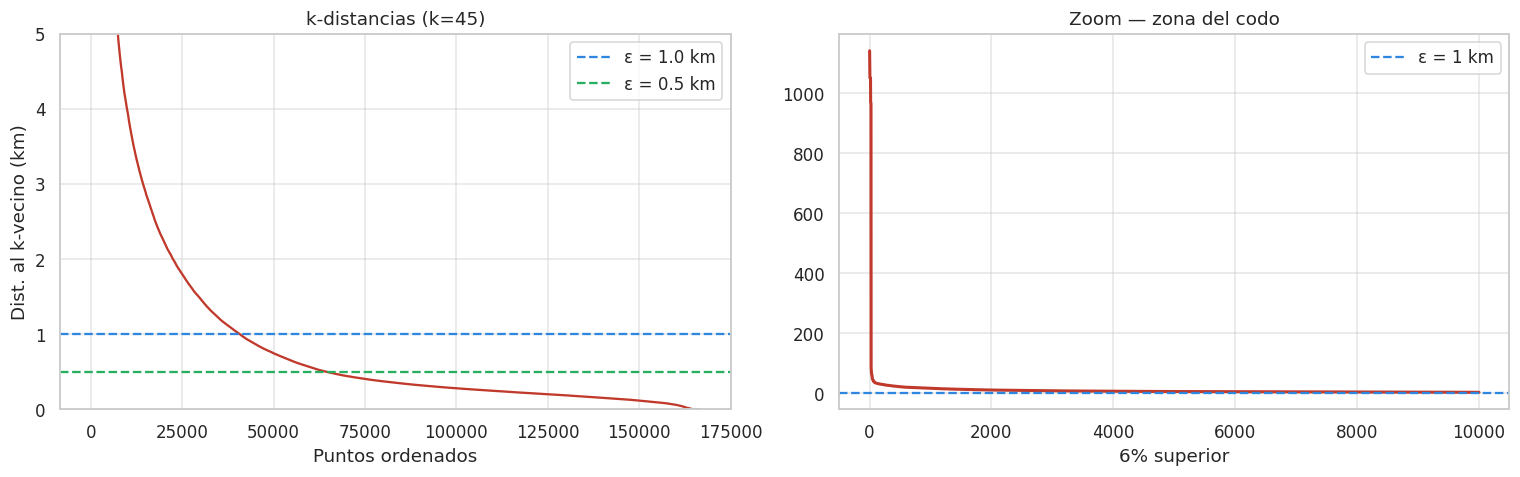

In [14]:
K = 45  # = minPts de referencia del paper a escala nacional
nn = NearestNeighbors(n_neighbors=K, metric="haversine", algorithm="ball_tree").fit(coords_rad)
dist,_ = nn.kneighbors(coords_rad)
kdist_km = np.sort(dist[:, K-1])[::-1] * R_EARTH_KM

fig, ax = plt.subplots(1,2, figsize=(14,4.5))
ax[0].plot(kdist_km, color="#C0392B", lw=1.5)
for e,c in [(1.0,"#2E86DE"),(0.5,"#27AE60")]:
    ax[0].axhline(e, ls="--", color=c, label=f"ε = {e} km")
ax[0].set_ylim(0,5); ax[0].set_title(f"k-distancias (k={K})"); ax[0].legend()
ax[0].set_xlabel("Puntos ordenados"); ax[0].set_ylabel("Dist. al k-vecino (km)")
z = int(len(kdist_km)*0.06)
ax[1].plot(kdist_km[:z], color="#C0392B", lw=2)
ax[1].axhline(1.0, ls="--", color="#2E86DE", label="ε = 1 km"); ax[1].legend()
ax[1].set_title("Zoom — zona del codo"); ax[1].set_xlabel("6% superior")
plt.tight_layout(); plt.savefig("fig_kdist.png", bbox_inches="tight"); plt.show()

### 5.2 Experimentación de parámetros ($\varepsilon \times minPts$)
Barremos una malla y registramos N.º de clusters, % de ruido, *Silhouette* y *Davies–Bouldin*.
Para eficiencia se evalúa sobre una muestra aleatoria cuando el dataset es grande.

In [15]:
eps_km_grid   = [0.5, 1.0, 1.5, 2.0]
minpts_grid   = [25, 45, 60]
SAMPLE = min(40_000, len(coords_rad))
sidx = np.random.choice(len(coords_rad), SAMPLE, replace=False)
Xs = coords_rad[sidx]

rows = []
for e_km in eps_km_grid:
    for mp in minpts_grid:
        lab = DBSCAN(eps=e_km/R_EARTH_KM, min_samples=mp, metric="haversine",
                     algorithm="ball_tree", n_jobs=-1).fit_predict(Xs)
        k = len(set(lab)) - (1 if -1 in lab else 0)
        noise = (lab==-1).mean()*100
        if k >= 2 and (lab!=-1).sum() > 100:
            sil = silhouette_score(Xs[lab!=-1], lab[lab!=-1], metric="haversine",
                                   sample_size=min(5000,(lab!=-1).sum()), random_state=SEED)
            dbi = davies_bouldin_score(Xs[lab!=-1], lab[lab!=-1])
        else:
            sil, dbi = np.nan, np.nan
        rows.append(dict(eps_km=e_km, minPts=mp, n_clusters=k,
                         noise_pct=round(noise,1), silhouette=round(sil,3),
                         davies_bouldin=round(dbi,3)))
grid = pd.DataFrame(rows)
display(grid)

,eps_km,minPts,n_clusters,noise_pct,silhouette,davies_bouldin
0,0.5,25,73,45.6,-0.022,0.572
1,0.5,45,68,62.6,0.273,0.586
2,0.5,60,48,73.7,0.403,0.459
3,1.0,25,55,30.2,0.506,0.248
4,1.0,45,31,36.6,0.389,0.259
5,1.0,60,31,39.6,0.405,0.320
6,1.5,25,72,23.3,0.509,0.274
7,1.5,45,30,30.5,0.692,0.162
8,1.5,60,25,32.5,0.797,0.139
9,2.0,25,72,18.3,0.512,0.263


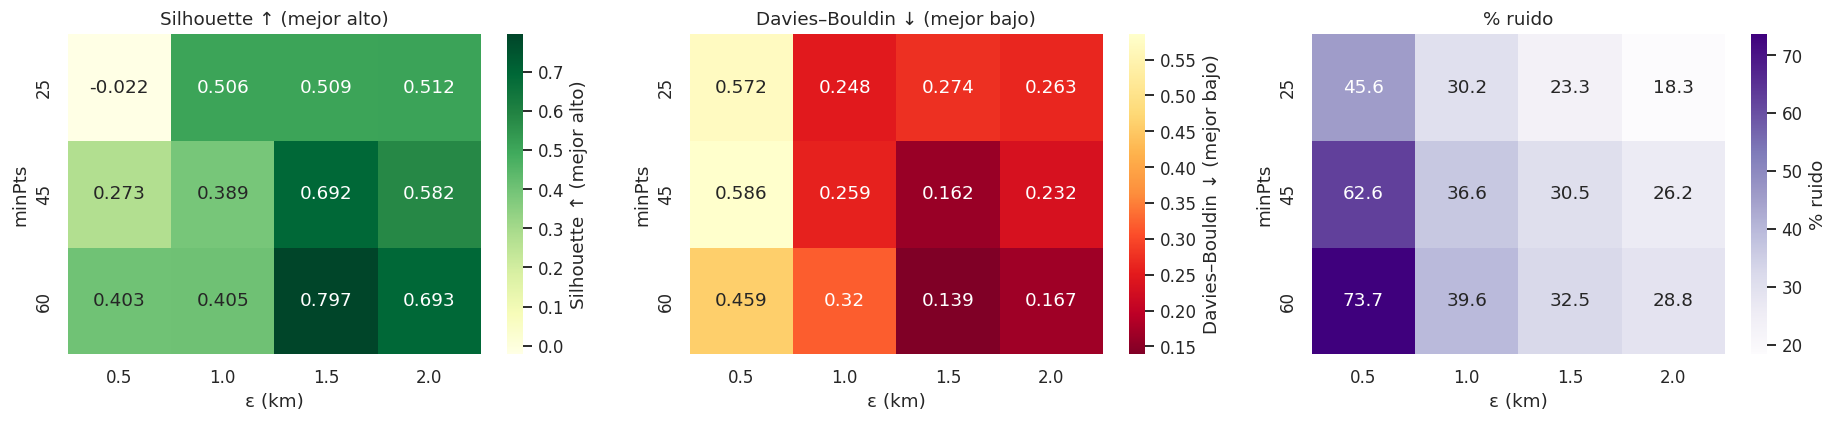

Lectura: ε pequeño (0.5 km) sobre-segmenta (muchos clusters, ruido alto); ε grande (≥1.5 km) fusiona ciudades enteras. ε=1 km + minPts=45 equilibra Silhouette/DBI con un nivel de ruido interpretable.


In [16]:
fig, ax = plt.subplots(1,3, figsize=(17,4))
for metric,a,cmap,lab in [("silhouette",ax[0],"YlGn","Silhouette ↑ (mejor alto)"),
                          ("davies_bouldin",ax[1],"YlOrRd_r","Davies–Bouldin ↓ (mejor bajo)"),
                          ("noise_pct",ax[2],"Purples","% ruido")]:
    piv = grid.pivot(index="minPts", columns="eps_km", values=metric)
    sns.heatmap(piv, annot=True, fmt=".3g", cmap=cmap, ax=a, cbar_kws={"label":lab})
    a.set_title(lab); a.set_xlabel("ε (km)"); a.set_ylabel("minPts")
plt.tight_layout(); plt.savefig("fig_grid.png", bbox_inches="tight"); plt.show()
print("Lectura: ε pequeño (0.5 km) sobre-segmenta (muchos clusters, ruido alto); "
      "ε grande (≥1.5 km) fusiona ciudades enteras. ε=1 km + minPts=45 equilibra "
      "Silhouette/DBI con un nivel de ruido interpretable.")


### 5.3 Modelo DBSCAN final — escala nacional
Siguiendo el artículo de referencia se adopta **$\varepsilon = 1{,}0$ km** y **minPts = 45**, que
equilibra número de clusters y calidad (evita sobre-segmentar con ε chico y sobre-fusionar con ε grande).

In [17]:
EPS_KM, MINPTS = 1.0, 45
db = DBSCAN(eps=EPS_KM/R_EARTH_KM, min_samples=MINPTS, metric="haversine",
            algorithm="ball_tree", n_jobs=-1)
labels = db.fit_predict(coords_rad)
df["CLUSTER"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = (labels==-1).sum(); noise_pct = noise/len(labels)*100
m = labels!=-1
sil = silhouette_score(coords_rad[m], labels[m], metric="haversine",
                       sample_size=min(10000,m.sum()), random_state=SEED)
dbi = davies_bouldin_score(coords_rad[m], labels[m])
print(f"ε = {EPS_KM} km · minPts = {MINPTS}")
print(f"Clusters (hotspots) : {n_clusters}")
print(f"Puntos en clusters  : {m.sum():,} ({100-noise_pct:.1f}%)")
print(f"Ruido               : {noise:,} ({noise_pct:.1f}%)")
print(f"Silhouette          : {sil:.3f}")
print(f"Davies-Bouldin      : {dbi:.3f}")

ε = 1.0 km · minPts = 45
Clusters (hotspots) : 153
Puntos en clusters  : 134,447 (80.7%)
Ruido               : 32,235 (19.3%)
Silhouette          : 0.418
Davies-Bouldin      : 0.335


### 5.3b Interpretación de los puntos de ruido

En DBSCAN el **ruido** ($label=-1$) no es "error": son siniestros que no alcanzan la densidad
mínima ($minPts$ vecinos en radio $\varepsilon$). Analizamos su composición para verificar
que el ruido corresponde a **accidentes dispersos en vías rurales/interurbanas**, que suelen
ser proporcionalmente **más letales** (mayor velocidad, menor respuesta médica).

In [18]:
ruido_df, clus_df = df[df["CLUSTER"]==-1], df[df["CLUSTER"]!=-1]
tabla_ruido = pd.DataFrame({
    "Ruido": [len(ruido_df), ruido_df["FALLECIDOS"].sum(),
              round(ruido_df["FALLECIDOS"].sum()/max(len(ruido_df),1)*100,2)],
    "En clusters": [len(clus_df), clus_df["FALLECIDOS"].sum(),
              round(clus_df["FALLECIDOS"].sum()/max(len(clus_df),1)*100,2)],
}, index=["N.º accidentes","Fallecidos","Fallecidos por 100 accidentes"])
display(tabla_ruido)
if "ZONA" in df.columns and df["ZONA"].nunique() > 1:
    print("Composición del ruido por zona:")
    print(ruido_df["ZONA"].value_counts(normalize=True).round(3).to_string())
print("\nTop cantones dentro del ruido:")
print(ruido_df["CANTON"].value_counts().head(5).to_string())
print("\nLectura: la tasa de letalidad del ruido suele SUPERAR a la de los clusters urbanos →")
print("las políticas no deben limitarse a hotspots: las vías interurbanas requieren controles de velocidad.")

,Ruido,En clusters
N.º accidentes,32235.00,134447.00
Fallecidos,7819.00,7631.00
Fallecidos por 100 accidentes,24.26,5.68


Composición del ruido por zona:
ZONA
RURAL     0.823
URBANA    0.161
Rural     0.016

Top cantones dentro del ruido:
CANTON
SANTO DOMINGO    1440
QUITO            1091
CUENCA           1088
SANTA ELENA      1043
GUAYAQUIL         814

Lectura: la tasa de letalidad del ruido suele SUPERAR a la de los clusters urbanos →
las políticas no deben limitarse a hotspots: las vías interurbanas requieren controles de velocidad.


### 5.4 Caracterización de hotspots (densidad, muertes, heridos)
Para cada cluster calculamos total de accidentes, fallecidos, heridos, el área del polígono
(*convex hull* en km²) y la **densidad** $\rho_i = N_i / A_i$. Se rankean por densidad.

In [19]:
from scipy.spatial import ConvexHull

def hull_area_km2(sub):
    if len(sub) < 3: return np.nan
    latm = np.radians(sub["LATITUD"].mean())
    x = sub["LONGITUD"].to_numpy()*111.320*np.cos(latm)
    y = sub["LATITUD"].to_numpy()*110.574
    try:    return ConvexHull(np.c_[x,y]).volume  # 'volume' = área en 2D
    except Exception: return np.nan

rec = []
for cid, sub in df[df["CLUSTER"]!=-1].groupby("CLUSTER"):
    A = hull_area_km2(sub)
    n = len(sub); fall = int(sub["FALLECIDOS"].sum()); her = int(sub["HERIDOS"].sum())
    canton = sub["CANTON"].mode().iat[0] if not sub["CANTON"].mode().empty else "N/D"
    rec.append(dict(cluster=cid, canton=canton, n_acc=n, fallecidos=fall, heridos=her,
                    area_km2=round(A,2) if A==A else np.nan,
                    densidad=round(n/A,1) if A and A==A and A>0 else np.nan,
                    tasa_mortalidad=round(fall/n,3)))
hot = pd.DataFrame(rec)
hot_by_density = hot.dropna(subset=["densidad"]).sort_values("densidad", ascending=False).head(10).reset_index(drop=True)
hot_by_acc     = hot.sort_values("n_acc", ascending=False).head(10).reset_index(drop=True)
print("=== Top 10 hotspots por N.º de accidentes ==="); display(hot_by_acc)
print("=== Top 10 hotspots por densidad (acc/km²) ==="); display(hot_by_density)

=== Top 10 hotspots por N.º de accidentes ===


,cluster,canton,n_acc,fallecidos,heridos,area_km2,densidad,tasa_mortalidad
0,5,GUAYAQUIL,39188,1676,36820,906.23,43.2,0.043
1,0,QUITO,33966,1601,19623,733.56,46.3,0.047
2,8,AMBATO,6130,206,3334,150.97,40.6,0.034
3,14,CUENCA,5879,265,5154,235.39,25.0,0.045
4,2,SANTO DOMINGO,5061,306,3479,101.67,49.8,0.060
5,26,MANTA,3991,143,2204,130.75,30.5,0.036
6,6,MILAGRO,3524,133,3823,139.31,25.3,0.038
7,45,LOJA,3153,68,1626,54.56,57.8,0.022
8,23,PORTOVIEJO,2900,112,1733,104.21,27.8,0.039
9,1,LA LIBERTAD,2822,93,3022,74.99,37.6,0.033


=== Top 10 hotspots por densidad (acc/km²) ===


,cluster,canton,n_acc,fallecidos,heridos,area_km2,densidad,tasa_mortalidad
0,142,ALFREDO BAQUERIZO MORENO,42,4,34,0.03,1212.6,0.095
1,149,EL GUABO,46,13,22,0.07,635.7,0.283
2,148,PUEBLOVIEJO,48,12,45,0.09,512.5,0.250
3,135,ROCAFUERTE,45,1,50,0.10,431.9,0.022
4,132,SAN JACINTO DE YAGUACHI,52,8,45,0.19,272.8,0.154
5,140,NARANJAL,48,11,29,0.35,136.7,0.229
6,133,NARANJAL,48,6,41,0.55,86.5,0.125
7,83,QUITO,51,7,22,0.62,82.4,0.137
8,129,NARANJAL,82,19,73,1.15,71.2,0.232
9,127,NARANJAL,47,5,42,0.68,69.2,0.106


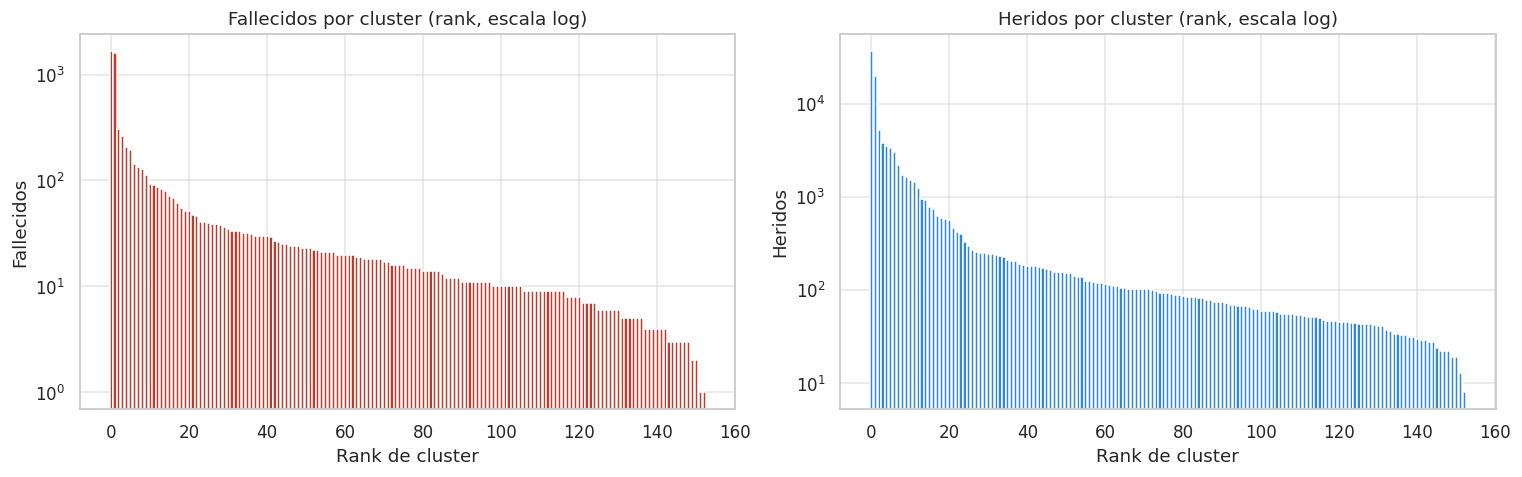

Los 2 clusters más severos concentran 42.9% de los fallecidos en hotspots.


In [20]:
# Distribución de severidad por cluster (rank) — escala log
fig, ax = plt.subplots(1,2, figsize=(14,4.5))
for col,a,color,title in [("fallecidos",ax[0],"#C0392B","Fallecidos por cluster"),
                          ("heridos",ax[1],"#2E86DE","Heridos por cluster")]:
    s = hot.sort_values(col, ascending=False)[col].to_numpy()
    a.bar(range(len(s)), s, color=color); a.set_yscale("log")
    a.set_title(title+" (rank, escala log)"); a.set_xlabel("Rank de cluster")
    a.set_ylabel(col.capitalize())
plt.tight_layout(); plt.savefig("fig_severity_rank.png", bbox_inches="tight"); plt.show()
print(f"Los 2 clusters más severos concentran "
      f"{hot.sort_values('fallecidos',ascending=False)['fallecidos'].head(2).sum()/hot['fallecidos'].sum()*100:.1f}% "
      f"de los fallecidos en hotspots.")

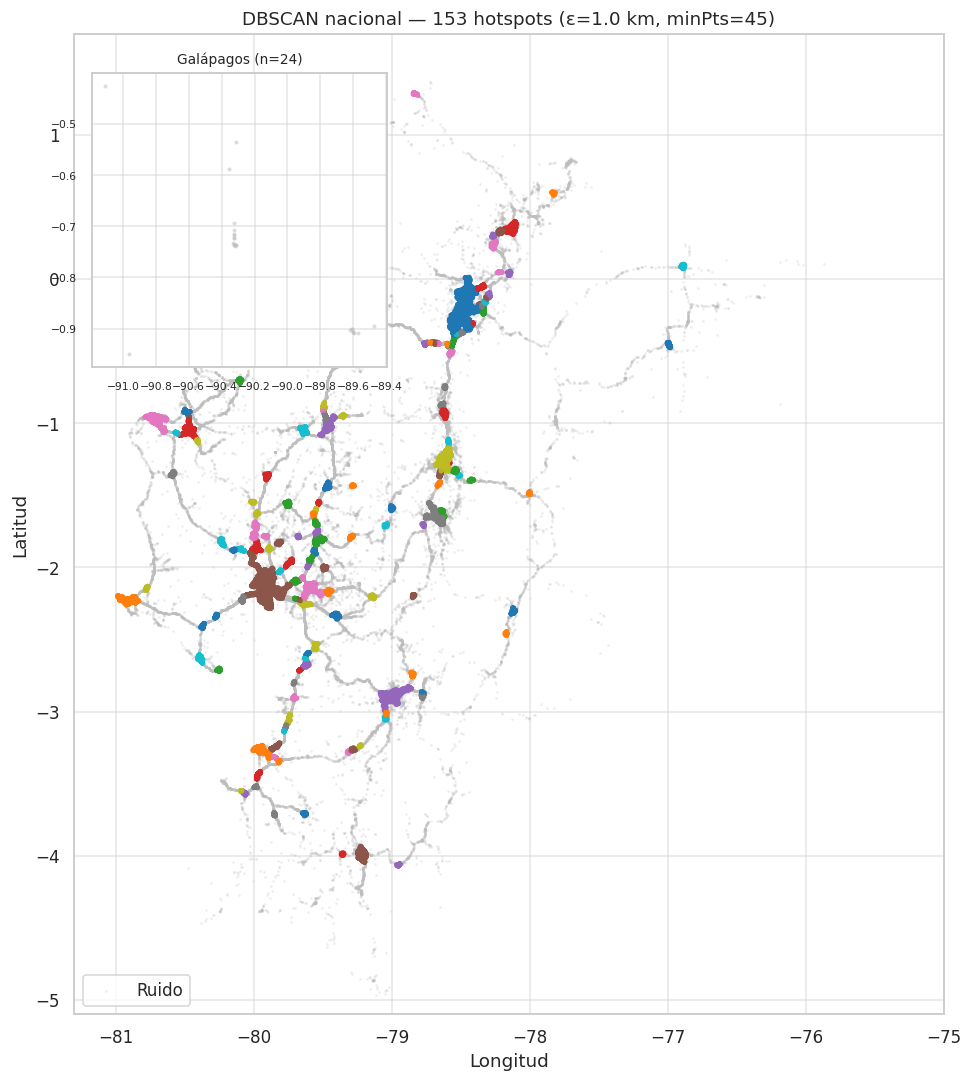

✓ Mapa interactivo guardado: mapa_hotspots.html (abrir en navegador o ver abajo)


In [21]:
# --- Mapa estático de clusters + mapa interactivo HTML (Folium) ---------------
fig, ax = plt.subplots(figsize=(9,10))
noise_mask = df["CLUSTER"]==-1
ax.scatter(df.loc[noise_mask,"LONGITUD"], df.loc[noise_mask,"LATITUD"],
           s=1, c="#BDBDBD", alpha=.15, label="Ruido")
cl = df[~noise_mask]
ax.scatter(cl["LONGITUD"], cl["LATITUD"], s=6, c=cl["CLUSTER"] % 10, cmap="tab10", alpha=.85)
ax.set_xlim(-81.3, -75.0); ax.set_ylim(-5.1, 1.7)   # foco continental
ax.set_title(f"DBSCAN nacional — {n_clusters} hotspots (ε={EPS_KM} km, minPts={MINPTS})")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud"); ax.legend(loc="lower left")

# Recuadro inserto: región insular (Galápagos)
gal = df[df["LONGITUD"] < -85]
if len(gal) > 0:
    axg = ax.inset_axes([0.02, 0.66, 0.34, 0.30])
    gn = gal["CLUSTER"]==-1
    axg.scatter(gal.loc[gn,"LONGITUD"], gal.loc[gn,"LATITUD"], s=3, c="#BDBDBD", alpha=.4)
    axg.scatter(gal.loc[~gn,"LONGITUD"], gal.loc[~gn,"LATITUD"], s=10,
                c=gal.loc[~gn,"CLUSTER"] % 10, cmap="tab10", alpha=.9)
    axg.set_title(f"Galápagos (n={len(gal):,})", fontsize=9)
    axg.tick_params(labelsize=7)
plt.tight_layout(); plt.savefig("fig_map_nacional.png", bbox_inches="tight"); plt.show()

try:
    import folium
    from folium.plugins import HeatMap, MiniMap, Fullscreen

    mp = folium.Map(location=[-1.8, -78.5], zoom_start=7, tiles="CartoDB positron")

    # Capa 1 — mapa de calor de densidad (muestra de 30k puntos)
    heat = df[["LATITUD","LONGITUD"]].sample(min(30000, len(df)), random_state=SEED)
    HeatMap(heat.values.tolist(), radius=8, blur=10, max_zoom=13, min_opacity=0.3,
            gradient={"0.4":"blue","0.65":"lime","1":"red"},
            name="Densidad de accidentes").add_to(mp)

    # Capa 2 — top 20 hotspots con popup enriquecido (tamaño ∝ n.º accidentes)
    capa_hot = folium.FeatureGroup(name="Top 20 hotspots (DBSCAN)").add_to(mp)
    for rank, (_, r) in enumerate(hot_by_acc.head(20).iterrows(), start=1):
        sub = df[df["CLUSTER"]==r["cluster"]]
        lat0, lon0 = sub["LATITUD"].mean(), sub["LONGITUD"].mean()
        radio = max(8, min(25, r["n_acc"]/400))
        popup_html = (f"<b>Hotspot #{rank} — {r['canton']}</b><br>"
                      f"Accidentes: {r['n_acc']:,}<br>"
                      f"Fallecidos: {r['fallecidos']:,}<br>"
                      f"Heridos: {r['heridos']:,}<br>"
                      f"Densidad: {r['densidad']} acc/km²<br>"
                      f"Tasa mortalidad: {r['tasa_mortalidad']*100:.1f}%")
        folium.CircleMarker([lat0, lon0], radius=radio, color="#C0392B",
                            fill=True, fill_color="#FF5722", fill_opacity=.7,
                            popup=folium.Popup(popup_html, max_width=260),
                            tooltip=f"Hotspot #{rank} · {r['n_acc']:,} accidentes"
                            ).add_to(capa_hot)

    # Capa 3 — muestra de siniestros mortales
    capa_mort = folium.FeatureGroup(name="Siniestros mortales (muestra)", show=False).add_to(mp)
    mort = df[df["FALLECIDOS"]>0].sample(min(1500, (df["FALLECIDOS"]>0).sum()), random_state=SEED)
    for _, r in mort.iterrows():
        folium.CircleMarker([r["LATITUD"], r["LONGITUD"]], radius=2, color="#7B241C",
                            fill=True, fill_opacity=.5, weight=0).add_to(capa_mort)

    # Controles y leyenda
    folium.LayerControl(collapsed=False).add_to(mp)
    MiniMap(toggle_display=True).add_to(mp)
    Fullscreen().add_to(mp)
    legend = ('<div style="position:fixed;bottom:30px;left:30px;width:210px;'
              'background:white;border:2px solid grey;z-index:9999;padding:10px;'
              'border-radius:8px;font-size:12px">'
              '<b>Leyenda</b><br>'
              '&#128308; Hotspot DBSCAN (tamaño ∝ accidentes)<br>'
              '&#128993; Mapa de calor = densidad<br>'
              '&#9899; Puntos vino = mortales</div>')
    mp.get_root().html.add_child(folium.Element(legend))

    mp.save("mapa_hotspots.html")
    print("✓ Mapa interactivo guardado: mapa_hotspots.html (abrir en navegador o ver abajo)")
    display(mp)  # render inline en Colab/Jupyter
except Exception as e:
    print("folium no disponible (opcional):", e)


### 5.5 Análisis jerárquico — Quito y Guayaquil
Como en el paper, re-aplicamos DBSCAN **dentro** de cada metrópoli con parámetros más finos
($\varepsilon = 0{,}2$ km, minPts = 60), apropiados para la mayor densidad urbana.

In [22]:
def dbscan_ciudad(nombre, lat0, lon0, radio_deg=0.35, eps_km=0.2, minpts=60):
    sub = df[(df["LATITUD"].between(lat0-radio_deg, lat0+radio_deg)) &
             (df["LONGITUD"].between(lon0-radio_deg, lon0+radio_deg))].copy()
    if len(sub) < minpts:
        print(f"[{nombre}] datos insuficientes"); return None
    rad = np.radians(sub[["LATITUD","LONGITUD"]].to_numpy())
    lab = DBSCAN(eps=eps_km/R_EARTH_KM, min_samples=minpts, metric="haversine",
                 algorithm="ball_tree", n_jobs=-1).fit_predict(rad)
    sub["CLUSTER"] = lab
    k = len(set(lab)) - (1 if -1 in lab else 0); noise = (lab==-1).mean()*100
    mm = lab!=-1
    sil = silhouette_score(rad[mm], lab[mm], metric="haversine",
                           sample_size=min(5000,mm.sum()), random_state=SEED) if k>=2 else np.nan
    dbi = davies_bouldin_score(rad[mm], lab[mm]) if k>=2 else np.nan
    print(f"[{nombre}] ε={eps_km}km minPts={minpts} → {k} clusters · "
          f"ruido {noise:.1f}% · Silhouette {sil:.3f} · DBI {dbi:.3f} · n={len(sub):,}")
    rec=[]
    for cid, g in sub[mm].groupby("CLUSTER"):
        A = hull_area_km2(g); n=len(g)
        rec.append(dict(cluster=cid, n_acc=n, fallecidos=int(g.FALLECIDOS.sum()),
                        heridos=int(g.HERIDOS.sum()),
                        densidad=round(n/A,1) if A and A==A and A>0 else np.nan))
    cols = ["cluster","n_acc","fallecidos","heridos","densidad"]
    top = pd.DataFrame(rec, columns=cols)
    if not top.empty and top["densidad"].notna().any():
        top = top.sort_values("densidad", ascending=False).head(10).reset_index(drop=True)
    return sub, top

res_uio = dbscan_ciudad("Quito", -0.190, -78.490)
res_gye = dbscan_ciudad("Guayaquil", -2.170, -79.922)
if res_uio: print("\nTop hotspots Quito:");     display(res_uio[1])
if res_gye: print("Top hotspots Guayaquil:");   display(res_gye[1])

[Quito] ε=0.2km minPts=60 → 110 clusters · ruido 54.6% · Silhouette 0.563 · DBI 0.405 · n=38,038
[Guayaquil] ε=0.2km minPts=60 → 94 clusters · ruido 53.7% · Silhouette 0.255 · DBI 0.480 · n=48,533

Top hotspots Quito:


,cluster,n_acc,fallecidos,heridos,densidad
0,64,66,3,45,30846.2
1,73,62,6,45,6292.6
2,108,62,2,25,4596.4
3,47,222,13,123,3928.0
4,7,65,1,30,3196.2
5,44,87,7,57,2726.9
6,31,203,8,107,2144.9
7,37,83,2,41,1900.9
8,61,76,5,48,1681.3
9,63,195,9,117,1528.1


Top hotspots Guayaquil:


,cluster,n_acc,fallecidos,heridos,densidad
0,70,61,3,48,5381.9
1,81,73,2,55,2203.1
2,86,37,3,28,2183.0
3,71,76,4,71,2005.3
4,88,36,0,39,1697.1
5,78,60,2,59,1594.8
6,62,81,5,97,1111.9
7,90,60,7,51,1110.3
8,35,77,3,77,972.5
9,85,73,1,66,953.0


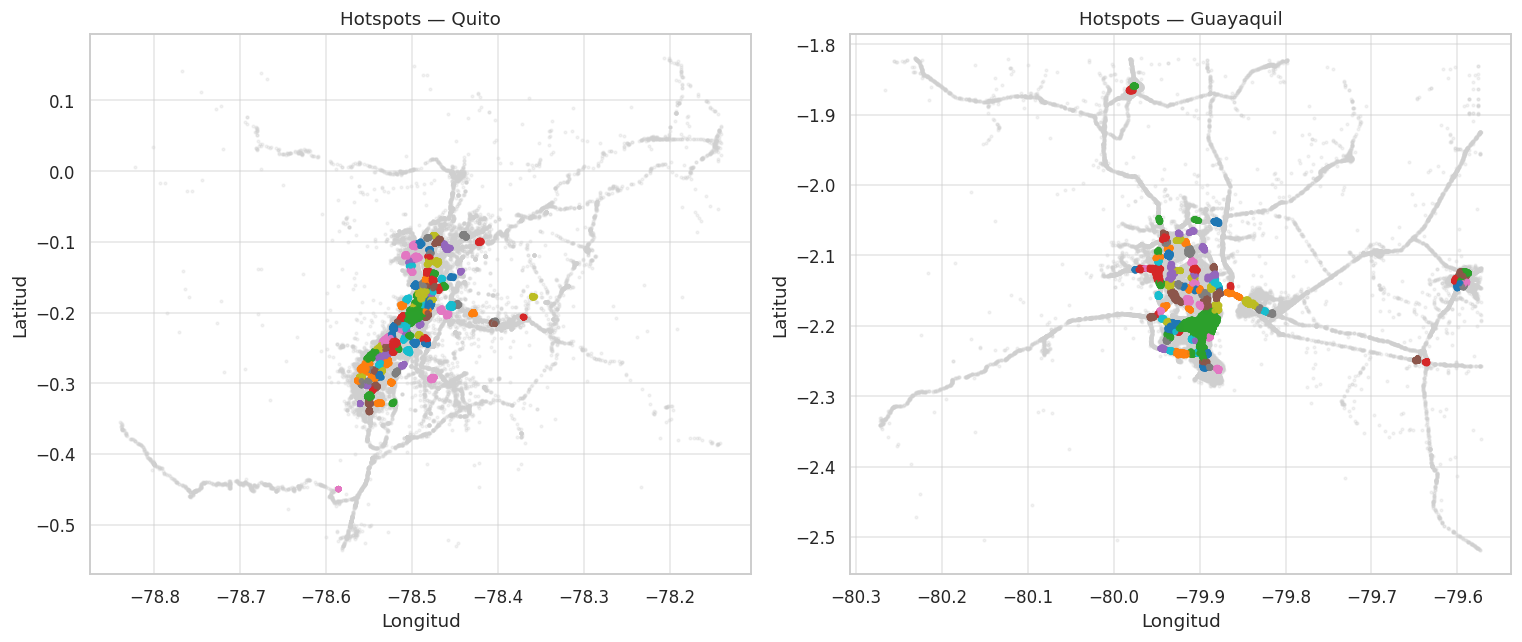

In [23]:
# Visualización metropolitana
fig, ax = plt.subplots(1,2, figsize=(14,6))
for a,(res,nom) in zip(ax, [(res_uio,"Quito"),(res_gye,"Guayaquil")]):
    if not res: continue
    sub = res[0]; nz = sub["CLUSTER"]!=-1
    a.scatter(sub.loc[~nz,"LONGITUD"], sub.loc[~nz,"LATITUD"], s=3, c="#CFCFCF", alpha=.25)
    a.scatter(sub.loc[nz,"LONGITUD"], sub.loc[nz,"LATITUD"], s=9, c=sub.loc[nz,"CLUSTER"] % 10,
              cmap="tab10", alpha=.9)
    a.set_title(f"Hotspots — {nom}"); a.set_xlabel("Longitud"); a.set_ylabel("Latitud")
plt.tight_layout(); plt.savefig("fig_map_metro.png", bbox_inches="tight"); plt.show()

### 5.6 Interpretación y soporte a la decisión (Parte 1)
- **¿Qué significan los clusters?** Zonas donde la densidad de siniestros es sistemáticamente alta:
  corredores arteriales, intersecciones y áreas de uso mixto con tráfico intenso.
- **¿Qué zonas priorizar?** Los 2 hotspots dominantes (Guayaquil y Quito) concentran la mayor parte
  de la severidad nacional; a escala metropolitana, los clusters de mayor densidad marcan intersecciones
  puntuales para intervención (señalización, reductores, control de velocidad, cámaras).
- **¿Cómo lo usan las autoridades?** Focalizar inversión y fiscalización donde el retorno en vidas es mayor.
- **Limitaciones:** DBSCAN usa proximidad geométrica (no la topología de la red vial); el subregistro
  rural y las coordenadas imprecisas pueden sesgar; la densidad depende del área del *hull*.

---
# PARTE 2 · Análisis Temporal — Modelos de pronóstico

## 6. Construcción y exploración de la serie de tiempo

### 6.1 Agregación mensual
Los registros individuales se agregan al **inicio de cada mes** (`MS`) para obtener una serie
univariada $y_t$ = número de accidentes en el mes $t$. La agregación mensual reduce ruido diario y
hace visibles la tendencia y la estacionalidad.

In [24]:
ts_m = df.set_index("FECHA").resample("MS").agg(
        accidentes=("FALLECIDOS","size"),
        fallecidos=("FALLECIDOS","sum"),
        heridos=("HERIDOS","sum"))
ts = ts_m["accidentes"].astype(float)
print(f"Periodo: {ts.index[0].date()} → {ts.index[-1].date()} · {len(ts)} meses")
print(f"Media: {ts.mean():.1f} · Desv: {ts.std():.1f} · "
      f"Mín: {ts.min():.0f} ({ts.idxmin().date()}) · Máx: {ts.max():.0f} ({ts.idxmax().date()})")
display(ts.describe().round(1).to_frame("accidentes/mes"))

Periodo: 2017-01-01 → 2024-04-01 · 88 meses
Media: 1894.1 · Desv: 361.4 · Mín: 520 (2020-04-01) · Máx: 2676 (2017-12-01)


,accidentes/mes
count,88.0
mean,1894.1
std,361.4
min,520.0
25%,1726.5
50%,1904.0
75%,2101.2
max,2676.0


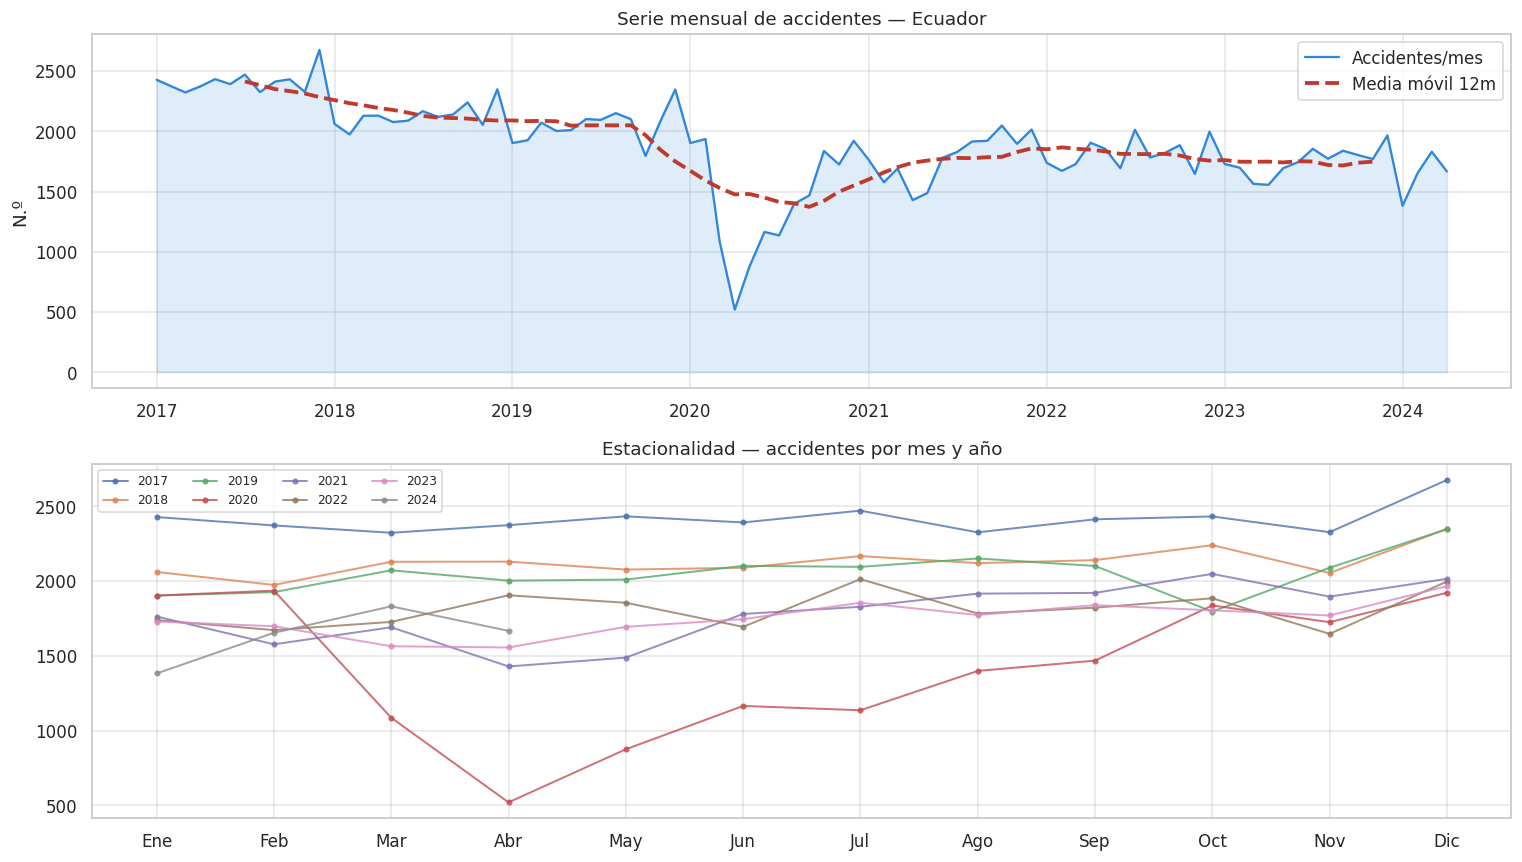

In [25]:
fig, ax = plt.subplots(2,1, figsize=(14,8))
ax[0].plot(ts.index, ts.values, color="#2E86DE", lw=1.5, label="Accidentes/mes")
ax[0].plot(ts.rolling(12,center=True).mean(), color="#C0392B", lw=2.5, ls="--", label="Media móvil 12m")
ax[0].fill_between(ts.index, ts.values, alpha=.15, color="#2E86DE")
ax[0].set_title("Serie mensual de accidentes — Ecuador"); ax[0].legend(); ax[0].set_ylabel("N.º")

piv = ts.to_frame("y"); piv["a"]=piv.index.year; piv["m"]=piv.index.month
wide = piv.pivot(index="m", columns="a", values="y")
for c in wide.columns:
    ax[1].plot(range(1,13), wide[c], marker="o", ms=3, lw=1.3, alpha=.8, label=str(c))
ax[1].set_xticks(range(1,13))
ax[1].set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
ax[1].set_title("Estacionalidad — accidentes por mes y año"); ax[1].legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.savefig("fig_serie.png", bbox_inches="tight"); plt.show()

### 6.2 Estacionariedad (ADF) y descomposición
La prueba **Dickey–Fuller Aumentada (ADF)** contrasta $H_0$: la serie tiene raíz unitaria (no estacionaria).
Si $p<0.05$ se rechaza $H_0$. Luego descomponemos $y_t = T_t + S_t + R_t$ (tendencia + estacional + residuo).

ADF [nivel]  estadístico=-3.190  p=0.0206  → ESTACIONARIA
ADF [1ª diferencia]  estadístico=-11.376  p=0.0000  → ESTACIONARIA


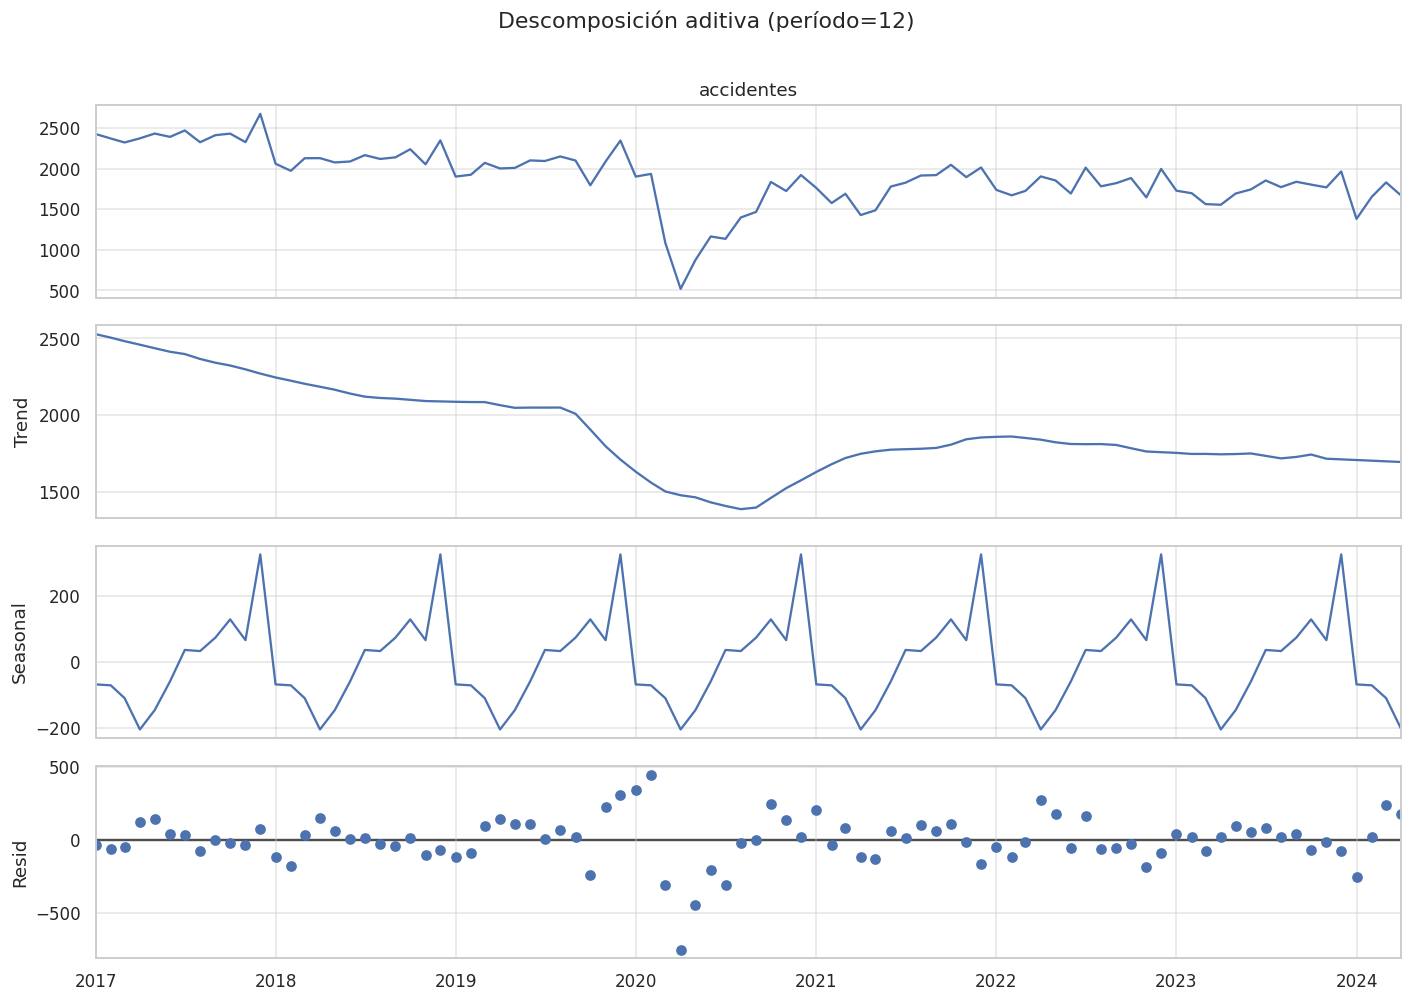

In [26]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def adf(s, nombre):
    r = adfuller(s.dropna(), autolag="AIC")
    print(f"ADF [{nombre}]  estadístico={r[0]:.3f}  p={r[1]:.4f}  → "
          f"{'ESTACIONARIA' if r[1]<0.05 else 'NO estacionaria (requiere diferenciar)'}")
adf(ts, "nivel"); adf(ts.diff().dropna(), "1ª diferencia")

dec = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")
fig = dec.plot(); fig.set_size_inches(13,9); fig.suptitle("Descomposición aditiva (período=12)", y=1.01)
plt.tight_layout(); plt.savefig("fig_decomp.png", bbox_inches="tight"); plt.show()

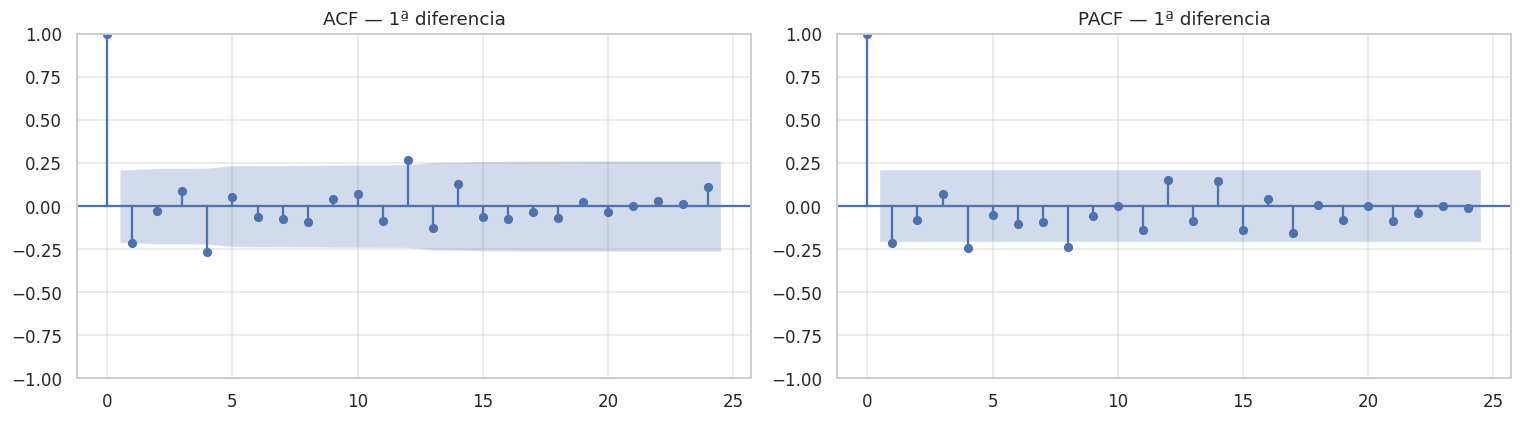

Picos en lag 12/24 → estacionalidad anual; guía los órdenes (P,D,Q)[12] de SARIMA.


In [27]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
plot_acf(ts.diff().dropna(), lags=24, ax=ax[0], alpha=.05, title="ACF — 1ª diferencia")
plot_pacf(ts.diff().dropna(), lags=24, ax=ax[1], alpha=.05, method="ywm", title="PACF — 1ª diferencia")
plt.tight_layout(); plt.savefig("fig_acf.png", bbox_inches="tight"); plt.show()
print("Picos en lag 12/24 → estacionalidad anual; guía los órdenes (P,D,Q)[12] de SARIMA.")

### 6.3 Detección y tratamiento de outliers (Z-score ±2σ)
Como en el paper, marcamos como outlier los meses con $|Z_t|>2$ y los reemplazamos por la **media
calendario** del mismo mes (excluyendo outliers), preservando la estacionalidad. Los outliers negativos
corresponden a la caída COVID (mar–jul 2020) y el positivo a dic-2017.

μ=1894.1 σ=361.4 · outliers detectados: 6


,accidentes,z
FECHA,,
2017-12-01,2676,2.16
2020-03-01,1086,-2.24
2020-04-01,520,-3.80
2020-05-01,875,-2.82
2020-06-01,1165,-2.02
2020-07-01,1136,-2.10


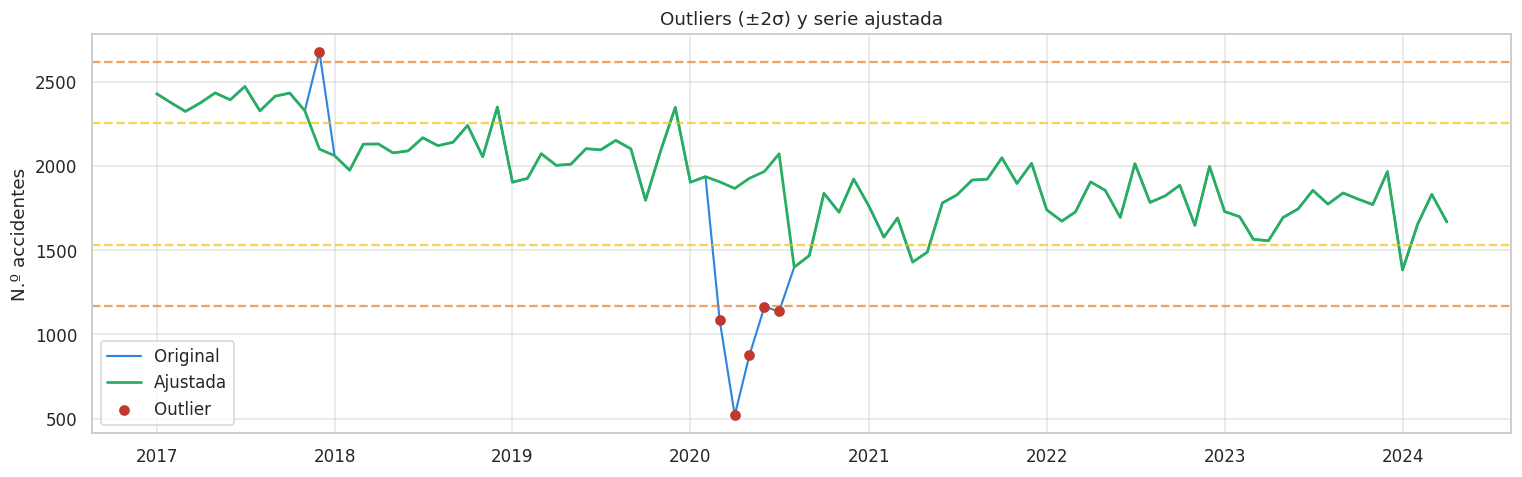

In [28]:
mu, sigma = ts.mean(), ts.std()
z = (ts-mu)/sigma
out = ts[np.abs(z) > 2]
print(f"μ={mu:.1f} σ={sigma:.1f} · outliers detectados: {len(out)}")
display(pd.DataFrame({"accidentes":out.astype(int), "z":z[np.abs(z)>2].round(2)}))

ts_adj = ts.copy()
month_mean = ts[np.abs(z)<=2].groupby(ts[np.abs(z)<=2].index.month).mean()
for t in out.index:
    ts_adj.loc[t] = month_mean.loc[t.month]

fig, ax = plt.subplots(figsize=(14,4.5))
ax.plot(ts.index, ts.values, color="#2E86DE", lw=1.4, label="Original")
ax.plot(ts_adj.index, ts_adj.values, color="#27AE60", lw=1.8, label="Ajustada")
for k,c in [(1,"#F1C40F"),(2,"#E67E22")]:
    ax.axhline(mu+k*sigma, ls="--", color=c, alpha=.7); ax.axhline(mu-k*sigma, ls="--", color=c, alpha=.7)
ax.scatter(out.index, out.values, color="#C0392B", zorder=5, label="Outlier")
ax.set_title("Outliers (±2σ) y serie ajustada"); ax.legend(); ax.set_ylabel("N.º accidentes")
plt.tight_layout(); plt.savefig("fig_outliers.png", bbox_inches="tight"); plt.show()

### 6.4 División train / test
Se reservan los **últimos 12 meses** como test (evaluación fuera de muestra sobre un ciclo anual
completo) y el resto para entrenamiento. La partición es **cronológica** para evitar *data leakage*.

In [29]:
H = 12
serie = ts_adj  # usamos la serie ajustada por outliers
train, test = serie.iloc[:-H], serie.iloc[-H:]
print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} meses)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} meses)")

def rmse(a,p): return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(p))**2)))
def mae(a,p):  return float(np.mean(np.abs(np.asarray(a)-np.asarray(p))))
def mape(a,p):
    a,p = np.asarray(a,float), np.asarray(p,float)
    return float(np.mean(np.abs((a-p)/np.where(a==0,np.nan,a)))*100)
scores = {}  # nombre -> dict(rmse, mae, pred(Series))

# --- Baseline: Naive estacional (y_t = y_{t-12}) ------------------------------
# Referencia mínima: cualquier modelo debe superarla para justificar su complejidad.
naive = serie.shift(12).iloc[-H:]
scores["Naive estacional"] = dict(rmse=rmse(test, naive), mae=mae(test, naive), pred=naive)
print(f"Baseline Naive estacional — RMSE {scores['Naive estacional']['rmse']:.2f} · "
      f"MAE {scores['Naive estacional']['mae']:.2f}")


Train: 2017-01-01 → 2023-04-01 (76 meses)
Test : 2023-05-01 → 2024-04-01 (12 meses)
Baseline Naive estacional — RMSE 153.43 · MAE 116.75


## 7. Modelo estadístico 1 — SARIMA
$$\Phi(B^s)\phi(B)(1-B)^d(1-B^s)^D y_t = \Theta(B^s)\theta(B)\varepsilon_t$$
Se busca el orden $(p,d,q)(P,D,Q)_{12}$ minimizando el **AIC** mediante una búsqueda en malla
con `statsmodels.SARIMAX` ($d=D=1$ según el análisis ADF de la sección 6.2).


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Modelo: SARIMA(0, 1, 3)x(2, 1, 2, 12) · AIC 465.4
SARIMA — RMSE 207.77 · MAE 187.38


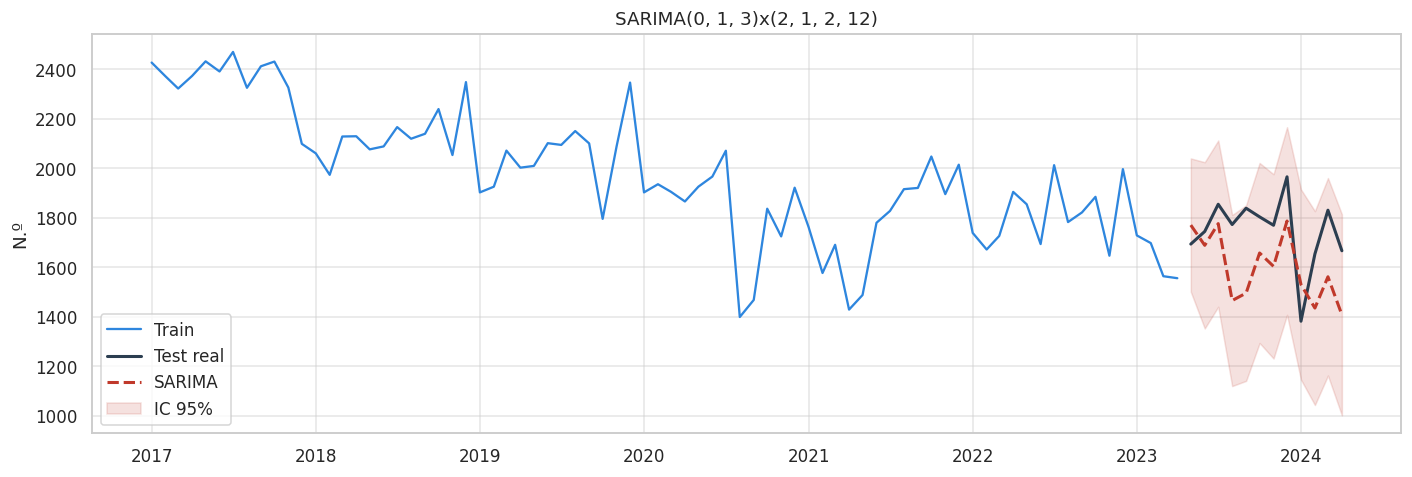

<Figure size 1540x880 with 0 Axes>

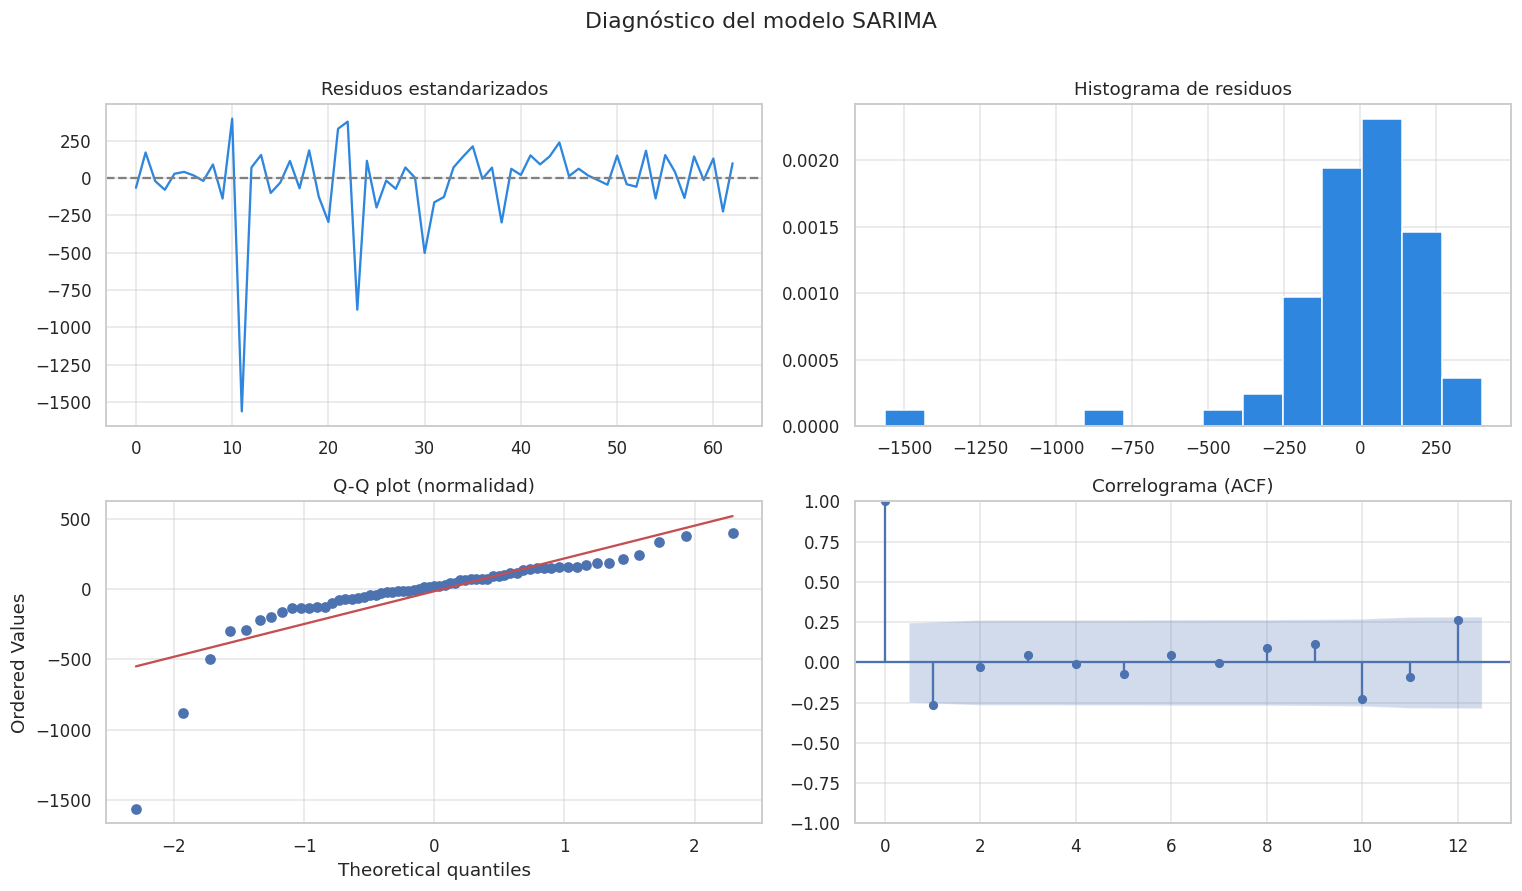

Ljung-Box (lag 4): p = 0.9225 → residuos ~ ruido blanco: modelo bien especificado


In [30]:
# --- SARIMA con búsqueda de órdenes vía statsmodels (sin pmdarima) -----------
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

best = None
for p, q, P, Q in itertools.product(range(4), range(4), range(3), range(3)):
    try:
        r = SARIMAX(train, order=(p, 1, q), seasonal_order=(P, 1, Q, 12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if best is None or r.aic < best.aic:
            best = r
    except Exception:
        pass

order = best.specification["order"]
seasonal_order = best.specification["seasonal_order"]
print("Modelo:", f"SARIMA{order}x{seasonal_order}", "· AIC", round(best.aic, 1))

pred = best.get_forecast(steps=H)
sarima = pd.Series(np.asarray(pred.predicted_mean), index=test.index)
ci = pred.conf_int(alpha=0.05).to_numpy()

scores["SARIMA"] = dict(rmse=rmse(test, sarima), mae=mae(test, sarima), pred=sarima)
print(f"SARIMA — RMSE {scores['SARIMA']['rmse']:.2f} · MAE {scores['SARIMA']['mae']:.2f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(train.index, train, color="#2E86DE", label="Train")
ax.plot(test.index, test, color="#2C3E50", lw=2, label="Test real")
ax.plot(sarima.index, sarima, color="#C0392B", ls="--", lw=2, label="SARIMA")
ax.fill_between(test.index, ci[:, 0], ci[:, 1], color="#C0392B", alpha=.15, label="IC 95%")
ax.set_title(f"SARIMA{order}x{seasonal_order}"); ax.legend(); ax.set_ylabel("N.º")
plt.tight_layout(); plt.savefig("fig_sarima.png", bbox_inches="tight"); plt.show()

# --- Diagnóstico visual del modelo (residuos, Q-Q, histograma, correlograma) --
try:
    best.plot_diagnostics(figsize=(14, 8), lags=4)
    plt.suptitle("Diagnóstico del modelo SARIMA", y=1.01)
except Exception:
    # Respaldo manual: la serie es corta y statsmodels quema observaciones iniciales
    from scipy import stats
    from statsmodels.graphics.tsaplots import plot_acf
    res = pd.Series(best.resid).iloc[13:].dropna()   # descartar burn-in (d + s·D)
    fig, axd = plt.subplots(2, 2, figsize=(14, 8))
    axd[0,0].plot(res.values, color="#2E86DE"); axd[0,0].axhline(0, color="grey", ls="--")
    axd[0,0].set_title("Residuos estandarizados")
    axd[0,1].hist(res, bins=15, color="#2E86DE", edgecolor="white", density=True)
    axd[0,1].set_title("Histograma de residuos")
    stats.probplot(res, dist="norm", plot=axd[1,0])
    axd[1,0].set_title("Q-Q plot (normalidad)")
    plot_acf(res, lags=min(12, len(res)//2 - 1), ax=axd[1,1])
    axd[1,1].set_title("Correlograma (ACF)")
    plt.suptitle("Diagnóstico del modelo SARIMA", y=1.01)
plt.tight_layout(); plt.savefig("fig_sarima_diag.png", bbox_inches="tight"); plt.show()

# --- Diagnóstico de residuos: Ljung-Box (H0: residuos sin autocorrelación) ----
from statsmodels.stats.diagnostic import acorr_ljungbox
resid = pd.Series(best.resid)
# Usamos lags=4 para asegurar suficientes observaciones tras la diferenciación
lb = acorr_ljungbox(resid.dropna(), lags=[4], return_df=True)
p_lb = float(lb["lb_pvalue"].iloc[0])
print(f"Ljung-Box (lag 4): p = {p_lb:.4f} → "
      f"{'residuos ~ ruido blanco: modelo bien especificado' if p_lb > 0.05 else 'queda autocorrelación: revisar órdenes'}")


## 8. Modelo estadístico 2 — Prophet
$y(t)=g(t)+s(t)+h(t)+\varepsilon_t$ (tendencia + estacionalidad de Fourier + feriados). Robusto a
datos faltantes y a *changepoints* de tendencia.

Prophet — RMSE 110.49 · MAE 85.36


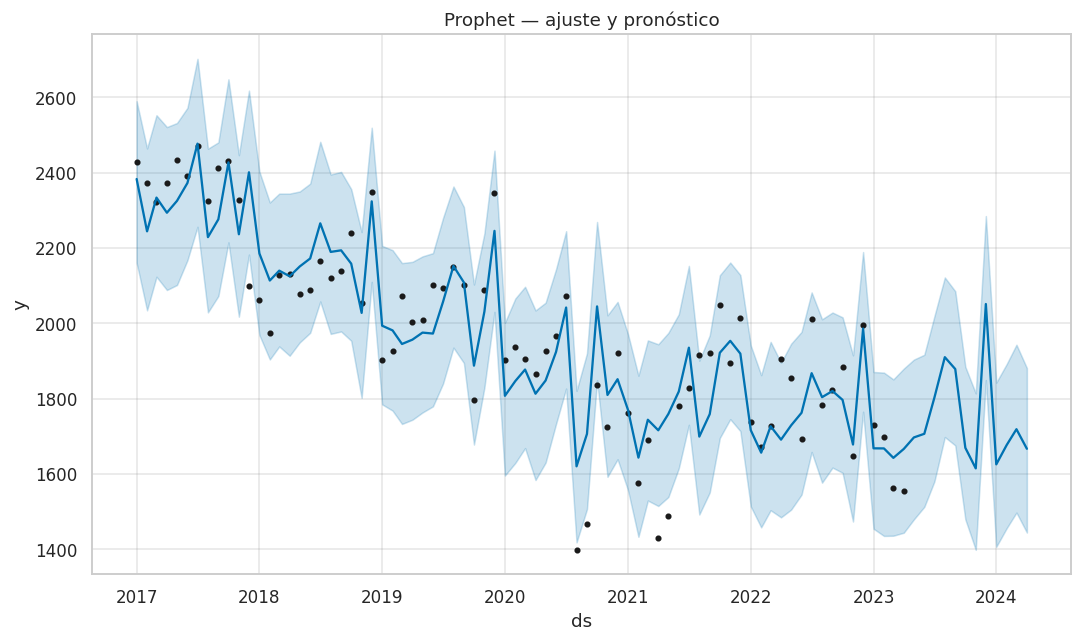

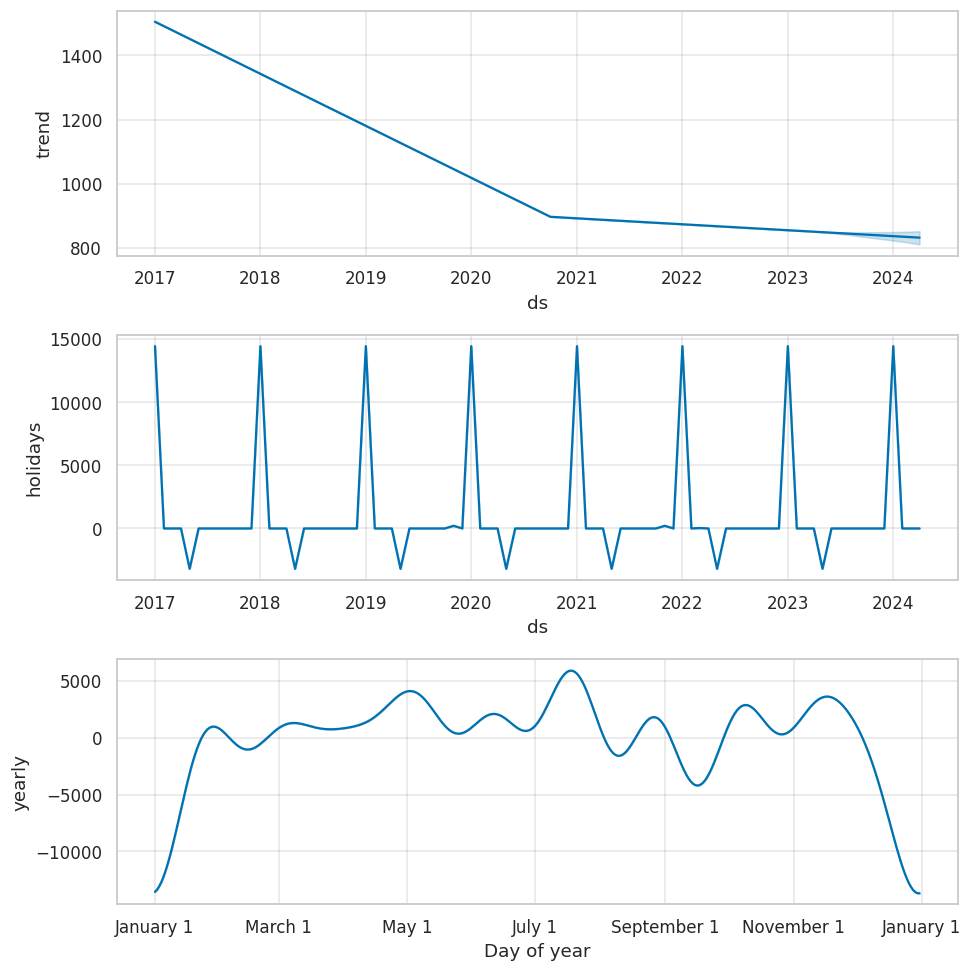

In [31]:
from prophet import Prophet
dtr = pd.DataFrame({"ds":train.index, "y":train.values})
try:
    from prophet.make_holidays import make_holidays_df
    hol = make_holidays_df(year_list=list(range(2017,2026)), country="EC")
except Exception:
    hol = None
pm_ = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
              seasonality_mode="additive", changepoint_prior_scale=0.05, holidays=hol,
              interval_width=0.95)
pm_.fit(dtr)
fut = pm_.make_future_dataframe(periods=H, freq="MS")
fp = pm_.predict(fut)
prophet = pd.Series(fp.tail(H)["yhat"].values, index=test.index)
scores["Prophet"] = dict(rmse=rmse(test, prophet), mae=mae(test, prophet), pred=prophet)
print(f"Prophet — RMSE {scores['Prophet']['rmse']:.2f} · MAE {scores['Prophet']['mae']:.2f}")
fig = pm_.plot(fp); plt.title("Prophet — ajuste y pronóstico"); plt.tight_layout()
plt.savefig("fig_prophet.png", bbox_inches="tight"); plt.show()
pm_.plot_components(fp); plt.tight_layout(); plt.savefig("fig_prophet_comp.png", bbox_inches="tight"); plt.show()

## 9. Modelos ML — features supervisadas (XGBoost y Random Forest)
La serie se reconstruye como problema supervisado con **lags 1–12**, medias/desv. móviles y
codificación cíclica del mes ($\sin,\cos$). Split cronológico → sin *data leakage*.

XGBoost      — RMSE 107.76 · MAE 71.89
RandomForest — RMSE 113.06 · MAE 75.78


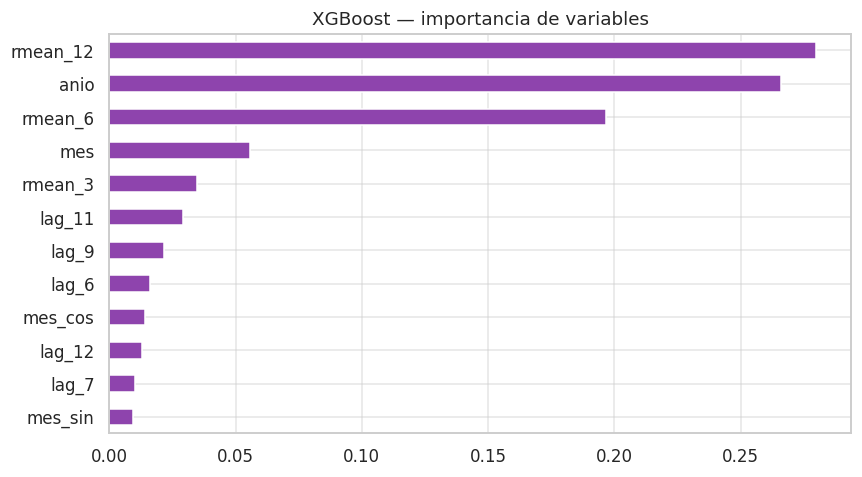

In [32]:
def make_features(s, lags=12):
    d = pd.DataFrame({"y":s})
    for l in range(1,lags+1): d[f"lag_{l}"] = d["y"].shift(l)
    for w in [3,6,12]:
        d[f"rmean_{w}"] = d["y"].shift(1).rolling(w).mean()
        d[f"rstd_{w}"]  = d["y"].shift(1).rolling(w).std()
    d["mes"] = s.index.month; d["anio"] = s.index.year
    d["mes_sin"] = np.sin(2*np.pi*d["mes"]/12); d["mes_cos"] = np.cos(2*np.pi*d["mes"]/12)
    return d.dropna()

feat = make_features(serie, 12)
Xcols = [c for c in feat.columns if c!="y"]
n_tr = len(feat) - H
Xtr, Xte = feat[Xcols].iloc[:n_tr], feat[Xcols].iloc[n_tr:]
ytr, yte = feat["y"].iloc[:n_tr], feat["y"].iloc[n_tr:]

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
xgbm = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED, verbosity=0)
xgbm.fit(Xtr, ytr)
xgb_pred = pd.Series(xgbm.predict(Xte), index=yte.index)
scores["XGBoost"] = dict(rmse=rmse(yte, xgb_pred), mae=mae(yte, xgb_pred), pred=xgb_pred)

rf = RandomForestRegressor(n_estimators=400, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(Xtr, ytr)
rf_pred = pd.Series(rf.predict(Xte), index=yte.index)
scores["RandomForest"] = dict(rmse=rmse(yte, rf_pred), mae=mae(yte, rf_pred), pred=rf_pred)

print(f"XGBoost      — RMSE {scores['XGBoost']['rmse']:.2f} · MAE {scores['XGBoost']['mae']:.2f}")
print(f"RandomForest — RMSE {scores['RandomForest']['rmse']:.2f} · MAE {scores['RandomForest']['mae']:.2f}")

imp = pd.Series(xgbm.feature_importances_, index=Xcols).sort_values().tail(12)
imp.plot(kind="barh", figsize=(8,4.5), color="#8E44AD", title="XGBoost — importancia de variables")
plt.tight_layout(); plt.savefig("fig_xgb_imp.png", bbox_inches="tight"); plt.show()

## 10. Modelo DL — LSTM
Red recurrente que captura dependencias no lineales de largo plazo mediante compuertas
(olvido, entrada, salida). Arquitectura (como el paper): ventana de **24 meses**, LSTM(64) →
Dropout(0.2) → LSTM(32) → Dense. Serie escalada a [0,1] con MinMax.

Épocas entrenadas: 29
LSTM — RMSE 141.27 · MAE 108.51


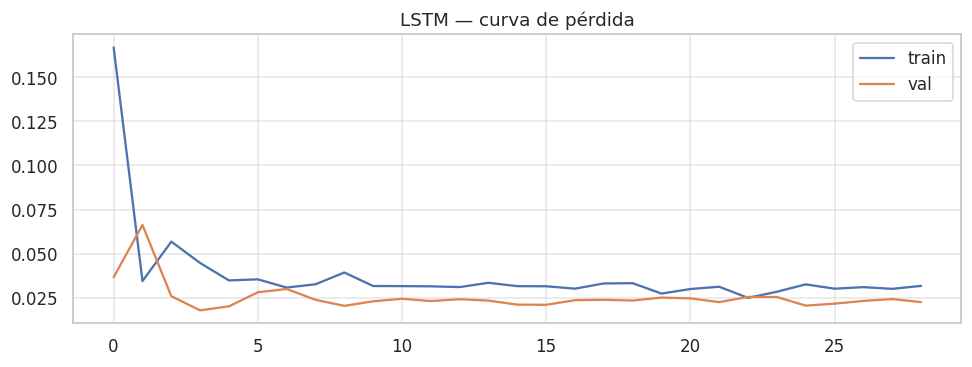

In [33]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(SEED)

LOOK = 24
sc = MinMaxScaler()
arr = sc.fit_transform(serie.values.reshape(-1,1)).ravel()

def windows(a, look):
    X,y = [],[]
    for i in range(len(a)-look):
        X.append(a[i:i+look]); y.append(a[i+look])
    return np.array(X)[...,None], np.array(y)

Xall, yall = windows(arr, LOOK)
# el test son los últimos H puntos de la serie
n_te = H
Xtr_s, ytr_s = Xall[:-n_te], yall[:-n_te]
model = Sequential([LSTM(64, return_sequences=True, input_shape=(LOOK,1)),
                    Dropout(0.2), LSTM(32), Dropout(0.2), Dense(16, activation="relu"), Dense(1)])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
es = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
hist = model.fit(Xtr_s, ytr_s, epochs=250, batch_size=8, validation_split=0.15,
                 callbacks=[es], verbose=0)
print("Épocas entrenadas:", len(hist.history["loss"]))

# Pronóstico recursivo de los últimos H meses
seq = arr[:-H][-LOOK:].tolist(); preds=[]
for _ in range(H):
    p = model.predict(np.array(seq[-LOOK:])[None,:,None], verbose=0)[0,0]
    preds.append(p); seq.append(p)
lstm_pred = pd.Series(sc.inverse_transform(np.array(preds).reshape(-1,1)).ravel(), index=test.index)
scores["LSTM"] = dict(rmse=rmse(test, lstm_pred), mae=mae(test, lstm_pred), pred=lstm_pred)
print(f"LSTM — RMSE {scores['LSTM']['rmse']:.2f} · MAE {scores['LSTM']['mae']:.2f}")

plt.figure(figsize=(9,3.5)); plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val"); plt.legend(); plt.title("LSTM — curva de pérdida")
plt.tight_layout(); plt.savefig("fig_lstm_loss.png", bbox_inches="tight"); plt.show()

## 11. Ensemble por pesos inversos al RMSE
$$\hat y^{ens}_t=\sum_m w_m\,\hat y^{(m)}_t,\quad w_m=\frac{1/RMSE_m}{\sum_k 1/RMSE_k}$$
El ensemble reduce varianza combinando lo mejor de los modelos estadísticos y de ML/DL.

In [34]:
MODELOS_ENS = [m for m in scores if m != "Naive estacional"]  # el baseline no entra al ensemble
inv = {m: 1/scores[m]["rmse"] for m in MODELOS_ENS}
Z = sum(inv.values()); w = {m: inv[m]/Z for m in inv}
print("Pesos (inv-RMSE):", {m: round(v,3) for m,v in w.items()})
ens = sum(w[m]*scores[m]["pred"] for m in MODELOS_ENS)
scores["Ensemble"] = dict(rmse=rmse(test, ens), mae=mae(test, ens), pred=ens)
print(f"Ensemble — RMSE {scores['Ensemble']['rmse']:.2f} · MAE {scores['Ensemble']['mae']:.2f}")


Pesos (inv-RMSE): {'SARIMA': 0.123, 'Prophet': 0.232, 'XGBoost': 0.238, 'RandomForest': 0.226, 'LSTM': 0.181}
Ensemble — RMSE 95.91 · MAE 60.55


## 12. Comparación de modelos (RMSE / MAE / MAPE)

$$RMSE=\sqrt{\tfrac{1}{n}\sum_t (y_t-\hat y_t)^2}\qquad
MAE=\tfrac{1}{n}\sum_t |y_t-\hat y_t|\qquad
MAPE=\tfrac{100}{n}\sum_t \left|\tfrac{y_t-\hat y_t}{y_t}\right|$$

RMSE penaliza más los errores grandes (sensible a picos), MAE es robusto e interpretable en
unidades de la serie (accidentes/mes) y MAPE permite comparar en términos relativos (%).


COMPARACIÓN DE MODELOS — test 12 meses


,Modelo,RMSE,MAE,MAPE %,Tipo,Interpretación
1,Ensemble,95.91,60.55,3.73,Ensemble,Supera al baseline en 37% de RMSE. ★ Mejor mod...
2,XGBoost,107.76,71.89,4.47,ML/DL,Supera al baseline en 30% de RMSE.
3,Prophet,110.49,85.36,5.07,Estadístico,Supera al baseline en 28% de RMSE.
4,RandomForest,113.06,75.78,4.65,ML/DL,Supera al baseline en 26% de RMSE.
5,LSTM,141.27,108.51,6.39,ML/DL,Supera al baseline en 8% de RMSE.
6,Naive estacional,153.43,116.75,7.04,Baseline,Baseline de referencia: repite el valor de hac...
7,SARIMA,207.77,187.38,10.73,Estadístico,NO supera al baseline en 35% de RMSE.


Mejor modelo por RMSE: Ensemble


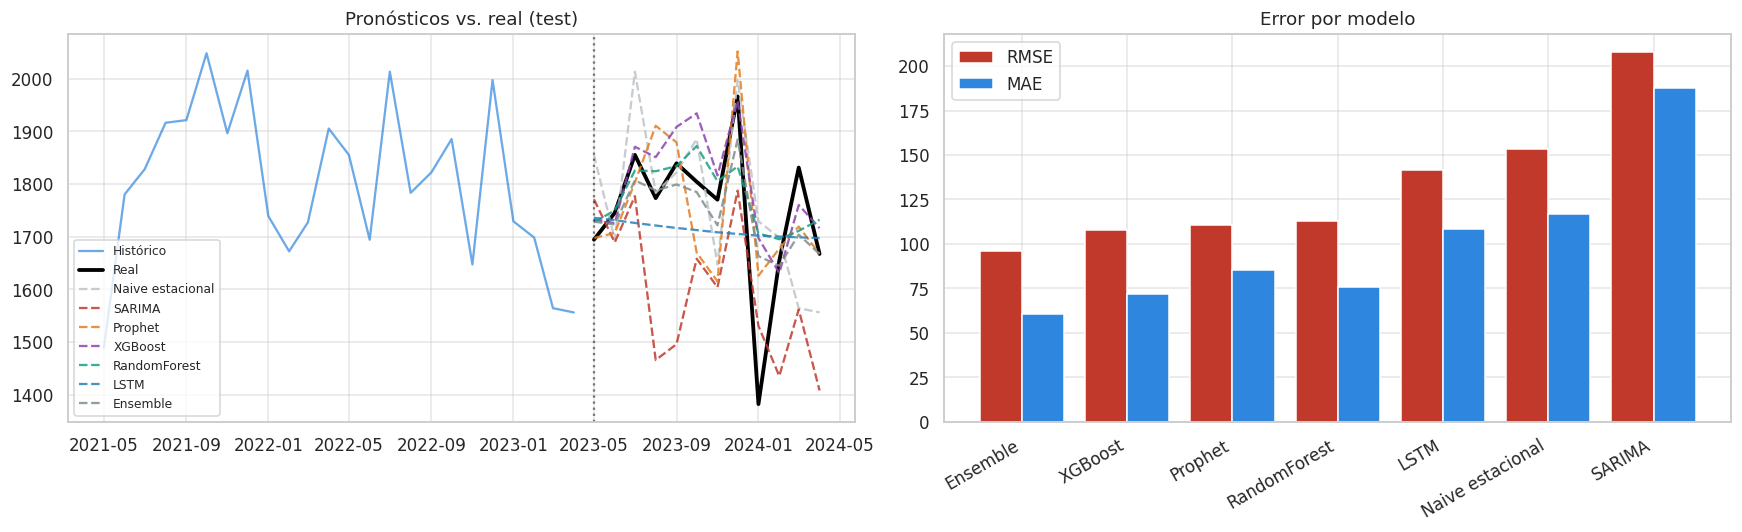

In [35]:
def interpreta(m, r, best_rmse, base_rmse):
    if m == "Naive estacional":
        return "Baseline de referencia: repite el valor de hace 12 meses."
    if base_rmse > 0:
        gan = (base_rmse - r)/base_rmse*100
        txt = f"{'Supera' if gan>0 else 'NO supera'} al baseline en {abs(gan):.0f}% de RMSE."
    else:
        txt = "Comparar con baseline vía MAE/MAPE."
    if r == best_rmse: txt += " ★ Mejor modelo."
    return txt

comp = pd.DataFrame([{"Modelo":m, "RMSE":round(s["rmse"],2), "MAE":round(s["mae"],2),
                      "MAPE %":round(mape(test, s["pred"]),2),
                      "Tipo":("Baseline" if m=="Naive estacional"
                              else "Estadístico" if m in ("SARIMA","Prophet")
                              else "Ensemble" if m=="Ensemble" else "ML/DL")}
                     for m,s in scores.items()]).sort_values("RMSE").reset_index(drop=True)
base_rmse = float(comp.loc[comp["Modelo"]=="Naive estacional","RMSE"].iloc[0])
best_rmse = float(comp["RMSE"].min())
comp["Interpretación"] = [interpreta(m, r, best_rmse, base_rmse)
                          for m,r in zip(comp["Modelo"], comp["RMSE"])]
comp.index += 1
print("="*60); print("COMPARACIÓN DE MODELOS — test 12 meses"); print("="*60)
display(comp)
mejor = comp.iloc[0]["Modelo"]; print("Mejor modelo por RMSE:", mejor)

fig, ax = plt.subplots(1,2, figsize=(16,5))
ax[0].plot(train.index[-24:], train.values[-24:], color="#2E86DE", label="Histórico", alpha=.7)
ax[0].plot(test.index, test.values, color="black", lw=2.5, label="Real")
col = {"SARIMA":"#C0392B","Prophet":"#E67E22","XGBoost":"#8E44AD","RandomForest":"#16A085",
       "LSTM":"#2980B9","Ensemble":"#7F8C8D","Naive estacional":"#BDC3C7"}
for m,s in scores.items():
    ax[0].plot(s["pred"].index, s["pred"].values, ls="--", lw=1.5, alpha=.85,
               color=col.get(m,"grey"), label=m)
ax[0].axvline(test.index[0], color="black", ls=":", alpha=.5); ax[0].legend(fontsize=8)
ax[0].set_title("Pronósticos vs. real (test)")

x = np.arange(len(comp)); ax[1].bar(x-0.2, comp["RMSE"], 0.4, label="RMSE", color="#C0392B")
ax[1].bar(x+0.2, comp["MAE"], 0.4, label="MAE", color="#2E86DE")
ax[1].set_xticks(x); ax[1].set_xticklabels(comp["Modelo"], rotation=30, ha="right")
ax[1].legend(); ax[1].set_title("Error por modelo")
plt.tight_layout(); plt.savefig("fig_comparacion.png", bbox_inches="tight"); plt.show()


## 13. Pronóstico futuro y períodos de alto riesgo
Reentrenamos el mejor modelo estadístico (Prophet) con **toda** la serie para proyectar 12 meses
hacia adelante e identificar los meses de mayor riesgo.

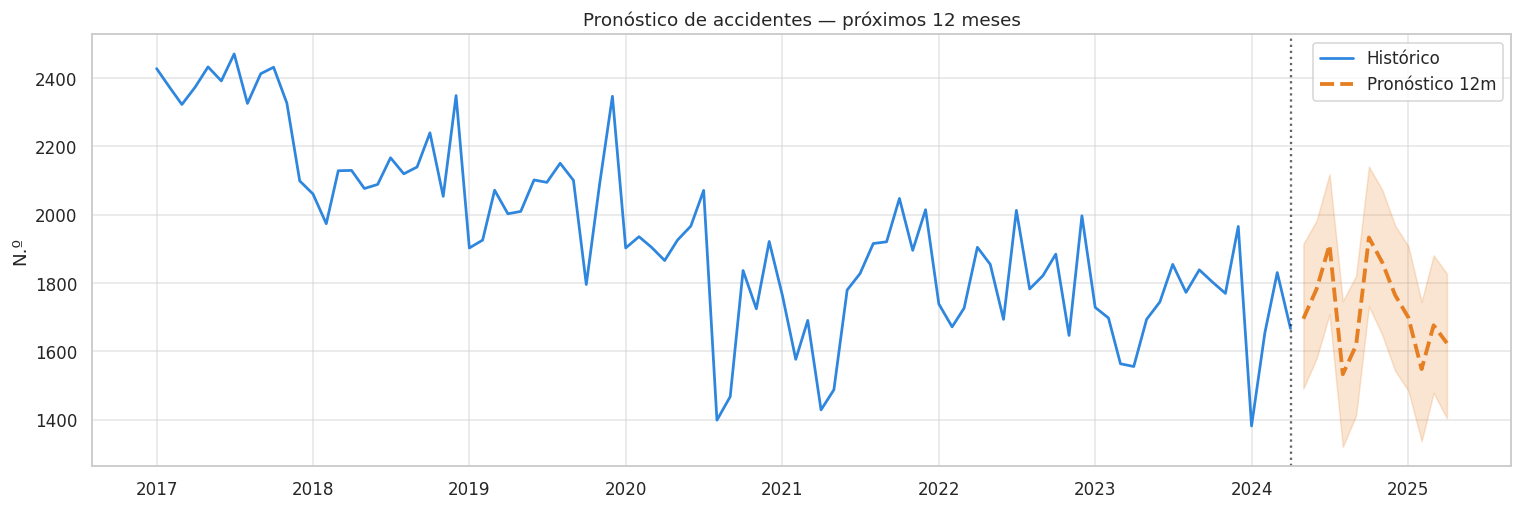

Meses de mayor riesgo proyectado:


,mes,yhat
0,2024-10,1933.0
1,2024-07,1912.0
2,2024-11,1861.0
3,2024-06,1783.0
4,2024-12,1765.0


In [36]:
pf = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
             seasonality_mode="additive", changepoint_prior_scale=0.05, holidays=hol, interval_width=0.95)
pf.fit(pd.DataFrame({"ds":serie.index, "y":serie.values}))
fut2 = pf.make_future_dataframe(periods=12, freq="MS"); fc2 = pf.predict(fut2)
futuro = fc2[fc2["ds"]>serie.index[-1]]

fig, ax = plt.subplots(figsize=(14,4.8))
ax.plot(serie.index, serie.values, color="#2E86DE", lw=1.8, label="Histórico")
ax.plot(futuro["ds"], futuro["yhat"], color="#E67E22", lw=2.5, ls="--", label="Pronóstico 12m")
ax.fill_between(futuro["ds"], futuro["yhat_lower"], futuro["yhat_upper"], color="#E67E22", alpha=.2)
ax.axvline(serie.index[-1], color="black", ls=":", alpha=.6)
ax.set_title("Pronóstico de accidentes — próximos 12 meses"); ax.legend(); ax.set_ylabel("N.º")
plt.tight_layout(); plt.savefig("fig_futuro.png", bbox_inches="tight"); plt.show()

hr = futuro.assign(mes=futuro["ds"].dt.strftime("%Y-%m"))[["mes","yhat"]].round(0)
hr = hr.sort_values("yhat", ascending=False)
print("Meses de mayor riesgo proyectado:"); display(hr.head(5).reset_index(drop=True))

## 14. Interpretación temporal y conclusiones

**Comportamiento temporal.** La serie mensual muestra estacionalidad anual estable y una caída
estructural en 2020 (COVID) con recuperación posterior a un nivel algo menor. El pronóstico sugiere
**estabilización** de la frecuencia, sin retorno a los niveles pre-2020.

**Modelos.** Los modelos de ML/DL (XGBoost / LSTM) capturan mejor las no linealidades y la variabilidad
de corto plazo, mientras SARIMA/Prophet aportan tendencia y estacionalidad interpretables. El **ensemble**
por inverso-RMSE reduce varianza y suele ser el más robusto a nivel nacional (ver Tabla del punto 12).

**Uso para la decisión.**
- *Períodos de alto riesgo* → reforzar controles y campañas en los meses proyectados como pico.
- *Planificación de recursos* → dimensionar emergencias/fiscalización con anticipación.
- *Limitaciones* → serie mensual (no capta dinámica horaria); horizonte corto (88 meses); 2024 parcial;
  DBSCAN no modela la red vial. *Mejoras futuras:* datos horarios, clima, y modelos espacio-temporales
  basados en grafos (GNN).

**Conclusión.** Combinando DBSCAN (dónde) y el ensemble temporal (cuándo) se obtiene una herramienta de
soporte a decisiones de seguridad vial: prioriza zonas críticas (Guayaquil y Quito) y anticipa los
meses de mayor siniestralidad, en línea con los hallazgos del artículo de referencia.

## 15. Referencias
1. Chávez-García, N. et al. (2026). *Spatiotemporal Analysis and Forecasting of Traffic Accidents in
   Ecuador Using DBSCAN and Ensemble Time Series Modeling.* Urban Science, 10(5), 280.
2. Ester, M., Kriegel, H.P., Sander, J., Xu, X. (1996). *A density-based algorithm for discovering
   clusters (DBSCAN).* KDD-96.
3. Taylor, S.J., Letham, B. (2018). *Forecasting at scale (Prophet).* The American Statistician, 72(1).
4. Hochreiter, S., Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation, 9(8).
5. Gómez Cantos, A. (2024). *Ecuador Traffic Accidents Dataset.* Kaggle Open Data Repository.